# NASA C-MAPSS — ML Pipeline (FD001 ~ FD004 통합 버전)

**CONFIG 의 `subset` 값으로 FD001 / FD002 / FD003 / FD004 전환**

| Subset | 운전조건 | 고장모드 | 클러스터링 |
|--------|---------|---------|-----------|
| FD001  | 1개     | 1개 (HPC)        | ❌ 없음 |
| FD002  | 6개     | 1개 (HPC)        | ✅ KMeans k=6 |
| FD003  | 1개     | 2개 (HPC + Fan)  | ❌ 없음 |
| FD004  | 6개     | 2개 (HPC + Fan)  | ✅ KMeans k=6 |

---

**분기 규칙** (자동 적용)
- `subset ∈ {FD001, FD003}` → 클러스터링 **스킵**, smoothing/normalize/OHE 모두 단일 그룹 처리
- `subset ∈ {FD002, FD004}` → KMeans(k=6), 클러스터별 smoothing/normalize, OHE 추가

후속 ML/Optuna 코드는 동일하게 작동 (피처 차원만 자동 변경됨).


## 0. 환경 & 라이브러리

In [17]:
# ── 라이브러리 체크 ──────────────────────────────────────────────────────
import importlib, subprocess, sys
_NEEDED = ['numpy','pandas','scikit-learn','scipy','matplotlib','seaborn',
           'xgboost','lightgbm','optuna','joblib']
_missing = []
for pkg in _NEEDED:
    mod = pkg.replace('-', '_')
    try:
        importlib.import_module('sklearn' if pkg == 'scikit-learn' else mod)
    except ImportError:
        _missing.append(pkg)
if _missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *_missing])
print(f'✅ 라이브러리 준비 완료 (설치: {_missing or "없음"})')

✅ 라이브러리 준비 완료 (설치: 없음)


In [18]:
import os, warnings, json, platform, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, GroupKFold, learning_curve
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── GPU 자동 감지 ─────────────────────────────────────────────────────────
def detect_gpu():
    try:
        out = subprocess.check_output(['nvidia-smi'], stderr=subprocess.DEVNULL)
        return True
    except Exception:
        return False

HAS_GPU    = detect_gpu()
XGB_DEVICE = 'cuda' if HAS_GPU else 'cpu'
LGB_DEVICE = 'gpu'  if HAS_GPU else 'cpu'
print(f'✅ GPU 감지: {HAS_GPU} | XGB={XGB_DEVICE} | LGBM={LGB_DEVICE}')

✅ GPU 감지: True | XGB=cuda | LGBM=gpu


In [19]:
# ── 컬럼 정의 ─────────────────────────────────────────────────────────────
RAW_COLS    = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1, 22)]
RENAME_MAP  = {
    'unit':'unit_nr', 'cycle':'time_cycles',
    'op1':'setting_1', 'op2':'setting_2', 'op3':'setting_3',
    **{f's{i}': f's_{i}' for i in range(1, 22)}
}
SENSOR_COLS = [f's_{i}' for i in range(1, 22)]
OP_COLS     = ['setting_1','setting_2','setting_3']
ID_COLS     = ['unit_nr','time_cycles']
print('✅ 컬럼 정의 완료')

✅ 컬럼 정의 완료


## 1. CONFIG — 파이프라인 파라미터

**핵심 키**
- `subset` : `'FD001'` / `'FD002'` / `'FD003'` / `'FD004'` 중 선택 → 클러스터링 분기 자동 결정
- `n_clusters` : FD002/FD004에서만 사용 (k=6 권장). FD001/FD003에서는 무시됨
- `manual_remove_sensors` : 수동 제거 센서 리스트
- `gaussian_sigma`, `normalize` 등은 subset 공통 — 필요 시 직접 조정


In [20]:
# ============================================================
# 🔧 CONFIG — 모든 파이프라인 파라미터를 여기서 조절
# ============================================================
CONFIG = {
    # ── ★ Subset 선택 (FD001 / FD002 / FD003 / FD004) ──
    'subset': 'FD001',

    # ── 센서 수동 제거 ──
    'manual_remove_sensors': ['s_1', 's_5', 's_6','s_10', 's_16', 's_18', 's_19'],
    # FD001 : 's_1', 's_5', 's_6','s_10', 's_16', 's_18', 's_19'
    # FD002 : 's_16' 
    # FD003,4 : 's_1', 's_5', 's_6','s_16', 's_18', 's_19'


    # ── 클러스터링 (FD002/FD004 에서만 사용) ──
    'n_clusters': 6,

    # ── RUL Cap ──
    'rul_cap': 120, # 120, 130, 130, 130

    # ── Gaussian sigma (None / 0 = skip) ──
    'gaussian_sigma': 2, # 2, 1, 3, 0
    'smoothing_method': 'gaussian',  # 'gaussian' / 'causal_ema'

    # ── 정규화 방식 ('minmax' / 'standard') ──
    'normalize': 'minmax', # minmax, standard, minmax, standard

    # ── 시계열 파생변수 ──  # 데이터셋 1, 데이터셋 2, 데이터셋 3, 데이터셋 4
    'rolling_means':[100], # [100] , [5, 40, 100] , [70] , [5, 50, 120]
    'diffs':        [60],  # [60] , [1, 50, 70] , [70] , [10, 50, 100]
    'lags':         [70],  # [70] , [1, 50, 100] , [40] , [1, 50, 100]
    'rolling_stds': [60],  # [60] , [10, 50, 100] , [70] , [10, 50, 100]
    'emas':         [70],  # [70] , [1, 20, 100] , [40] , [5, 50, 120]
}

CONST_THR    = 0.01
RANDOM_STATE = 42
VALID_RATIO  = 0.2

# ── 분기 플래그 자동 결정 ──
_VALID_SUBSETS = {'FD001', 'FD002', 'FD003', 'FD004'}
assert CONFIG['subset'] in _VALID_SUBSETS, f"subset must be one of {_VALID_SUBSETS}"
USE_CLUSTERING = CONFIG['subset'] in ('FD002', 'FD004')
EFFECTIVE_K    = CONFIG['n_clusters'] if USE_CLUSTERING else 1

print('✅ CONFIG 로드 완료')
print(f"   ► Subset         : {CONFIG['subset']}")
print(f"   ► Use clustering : {USE_CLUSTERING}  (effective k = {EFFECTIVE_K})")
for k, v in CONFIG.items():
    if k == 'subset': continue
    print(f'   {k:24s}: {v}')
print(f'\n   CONST_THR={CONST_THR} | VALID_RATIO={VALID_RATIO} | RANDOM_STATE={RANDOM_STATE}')


✅ CONFIG 로드 완료
   ► Subset         : FD001
   ► Use clustering : False  (effective k = 1)
   manual_remove_sensors   : ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
   n_clusters              : 6
   rul_cap                 : 120
   gaussian_sigma          : 2
   smoothing_method        : gaussian
   normalize               : minmax
   rolling_means           : [100]
   diffs                   : [60]
   lags                    : [70]
   rolling_stds            : [60]
   emas                    : [70]

   CONST_THR=0.01 | VALID_RATIO=0.2 | RANDOM_STATE=42


## 2. 데이터 로딩

In [21]:
SUBSET = CONFIG['subset']  # e.g. 'FD001'

DATA_DIR = 'CMAPSSData'
for c in ['CMAPSSData', '../../CMAPSSData', '../CMAPSSData']:
    if os.path.exists(os.path.join(c, f'train_{SUBSET}.txt')):
        DATA_DIR = c; break
else:
    print(f'⚠️ CMAPSSData 폴더를 찾지 못했습니다. 현재 위치: {os.getcwd()}')

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_{SUBSET}.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_{SUBSET}.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_{SUBSET}.txt',
                        sep=r'\s+', header=None, names=['RUL'], engine='python')

train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename( columns=RENAME_MAP, inplace=True)

print(f'✅ {SUBSET} 로딩 완료')
print(f'   Train : {train_raw.shape}  | 엔진 {train_raw["unit_nr"].nunique()}대')
print(f'   Test  : {test_raw.shape}   | 엔진 {test_raw["unit_nr"].nunique()}대')
print(f'   RUL   : {rul_df.shape}')
train_raw.head(3)


✅ FD001 로딩 완료
   Train : (20631, 26)  | 엔진 100대
   Test  : (13096, 26)   | 엔진 100대
   RUL   : (100, 1)


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442


## 3. 파이프라인 함수 정의 (FD001~FD004 통합)

**`USE_CLUSTERING` 플래그로 분기**

1. `filter_useful_sensors` — 수동 제거만
2. **(분기)** `cluster_op_conditions` — FD002/FD004만 실행, FD001/FD003은 `op_cluster=0` 부여
3. `add_piecewise_rul` — Cap 적용
4. **(분기)** smoothing — `(unit × cluster)` or `(unit)`
5. `split_by_unit` — 엔진 단위 random
6. **(분기)** normalize — 클러스터별 or 전체
7. `add_temporal_features` — unit 단위 lag/diff/roll/std/ema (공통)
8. **(분기)** OHE — FD002/FD004만


In [22]:
# ============================================================
# 파이프라인 함수 (FD001~FD004 통합 — USE_CLUSTERING 분기)
# ============================================================

def filter_useful_sensors(sensor_cols, manual_remove):
    """수동 제거 리스트만 적용 — 자동 제거 없음"""
    remove = sorted(list(set(manual_remove or [])))
    useful = [s for s in sensor_cols if s not in remove]
    useful = sorted(useful, key=lambda x: int(x.split('_')[1]) if '_' in x else x)
    return useful, remove


def cluster_op_conditions(train_df, test_df, op_cols, n_clusters,
                          random_state=RANDOM_STATE):
    """FD002/FD004: setting_1/2/3 MinMax → KMeans(k=n_clusters)"""
    op_scaler  = MinMaxScaler()
    op_train_z = op_scaler.fit_transform(train_df[op_cols])
    op_test_z  = op_scaler.transform(test_df[op_cols])

    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state,
                    n_init=20, max_iter=300)
    kmeans.fit(op_train_z)

    train_df = train_df.copy()
    test_df  = test_df.copy()
    train_df['op_cluster'] = kmeans.labels_
    test_df['op_cluster']  = kmeans.predict(op_test_z)
    return train_df, test_df, op_scaler, kmeans


def assign_dummy_cluster(train_df, test_df):
    """FD001/FD003: 클러스터링 스킵 — op_cluster=0 단일 그룹 부여"""
    train_df = train_df.copy()
    test_df  = test_df.copy()
    train_df['op_cluster'] = 0
    test_df['op_cluster']  = 0
    return train_df, test_df


def add_piecewise_rul(df, cap):
    """엔진별 RUL = max(cycle) - cycle, cap 적용"""
    df  = df.copy()
    mc  = df.groupby('unit_nr')['time_cycles'].max().rename('max_c')
    df  = df.join(mc, on='unit_nr')
    df['RUL_raw'] = df['max_c'] - df['time_cycles']
    df['RUL']     = df['RUL_raw'].clip(upper=cap)
    return df.drop('max_c', axis=1)


def apply_gaussian_smoothing(df, features, sigma, use_clustering):
    """(unit × cluster) 또는 (unit) 단위 가우시안 스무딩"""
    df  = df.copy().sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
    grp_cols = ['unit_nr','op_cluster'] if use_clustering else ['unit_nr'] #####
    grp = df.groupby(grp_cols)
    def _smooth(s):
        arr = s.values.astype(np.float32)
        if len(arr) > 1:
            return pd.Series(gaussian_filter1d(arr, sigma=sigma, mode='nearest'),
                             index=s.index)
        return s
    for col in features:
        df[col] = grp[col].transform(_smooth)
    return df

#####
def apply_causal_ema_smoothing(df, features, sigma, use_clustering):
    """[누수 없음] (unit × cluster) 또는 (unit) 단위 causal EMA. span=2σ+1"""
    span = 2 * sigma + 1
    df  = df.copy().sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
    grp_cols = ['unit_nr','op_cluster'] if use_clustering else ['unit_nr'] #####
    grp = df.groupby(grp_cols)
    for col in features:
        df[col] = grp[col].transform(
            lambda x: x.ewm(span=span, adjust=False).mean())
    return df


def split_by_unit(train_df, valid_ratio=VALID_RATIO, random_state=RANDOM_STATE):
    """엔진 단위 random split — 누수 방지"""
    units = train_df['unit_nr'].unique()
    sub_u, val_u = train_test_split(units, test_size=valid_ratio,
                                    random_state=random_state)
    sub = train_df[train_df['unit_nr'].isin(sub_u)].copy().reset_index(drop=True)
    val = train_df[train_df['unit_nr'].isin(val_u)].copy().reset_index(drop=True)
    return sub, val, sub_u, val_u


def normalize_features(sub, val, test, features, n_clusters, method, use_clustering):
    """USE_CLUSTERING 분기:
    - True  : 클러스터별 scaler (FD002/FD004)
    - False : 전체 sub-train fit, val/test transform (FD001/FD003)
    """
    ScalerCls = {'minmax': MinMaxScaler, 'standard': StandardScaler}[method]
    sub  = sub.copy();  val  = val.copy();  test = test.copy()
    scalers = {}

    if not use_clustering:
        # ── 전체 fit (FD001/FD003) ──
        scaler = ScalerCls()
        sub[features]  = scaler.fit_transform(sub[features])
        val[features]  = scaler.transform(val[features])
        test[features] = scaler.transform(test[features])
        scalers[0] = scaler
        return sub, val, test, scalers

    # ── 클러스터별 fit (FD002/FD004) ──
    for c in range(n_clusters):
        mask_s = sub['op_cluster'] == c
        if mask_s.sum() == 0:
            scaler_c = ScalerCls()
            scaler_c.fit(sub[features])
        else:
            scaler_c = ScalerCls()
            sub.loc[mask_s, features] = scaler_c.fit_transform(sub.loc[mask_s, features])
        scalers[c] = scaler_c

    for df_target in (val, test):
        for c in range(n_clusters):
            mask = df_target['op_cluster'] == c
            if mask.sum() > 0:
                df_target.loc[mask, features] = scalers[c].transform(
                    df_target.loc[mask, features])
    return sub, val, test, scalers

def add_temporal_features(df, sensor_cols,
                          lags, diffs, rolls, roll_stds, emas,
                          use_clustering):
    """unit 또는 (unit×cluster) 단위 시계열 파생변수"""
    df = df.copy().sort_values(['unit_nr','time_cycles']).reset_index(drop=True)

    grp_cols = ['unit_nr'] if use_clustering else ['unit_nr'] ###### ,'op_cluster' 제외

    for s in sensor_cols:
        grp = df.groupby(grp_cols)[s]

        for lag in (lags or []):
            df[f'{s}_lag{lag}'] = grp.shift(lag)

        for d in (diffs or []):
            df[f'{s}_diff{d}'] = grp.diff(d)

        for r in (rolls or []):
            df[f'{s}_roll{r}'] = grp.transform(
                lambda x: x.rolling(r, min_periods=1).mean())

        for r in (roll_stds or []):
            df[f'{s}_rollstd{r}'] = grp.transform(
                lambda x: x.rolling(r, min_periods=1).std().fillna(0))

        for span in (emas or []):
            df[f'{s}_ema{span}'] = grp.transform(
                lambda x: x.ewm(span=span, adjust=False).mean())

    return df.fillna(0)



def add_ohe_cluster(df, n_clusters):
    """FD002/FD004: op_cluster 원핫인코딩"""
    df = df.copy()
    df = df.drop(columns=[c for c in df.columns if c.startswith('cluster_')], errors='ignore')
    
    ohe_cols = [f'cluster_{i}' for i in range(n_clusters)]
    ohe = pd.get_dummies(df['op_cluster'], prefix='cluster').astype(np.float32)
    for col in ohe_cols:
        if col not in ohe.columns:
            ohe[col] = np.float32(0.0)
    out = pd.concat([df.reset_index(drop=True),
                     ohe[ohe_cols].reset_index(drop=True)], axis=1)
    return out, ohe_cols


def run_pipeline(train_raw, test_raw, cfg):
    """FD001~FD004 통합 전처리 파이프라인 (USE_CLUSTERING 분기)"""
    use_cluster = cfg['subset'] in ('FD002', 'FD004')
    eff_k       = cfg['n_clusters'] if use_cluster else 1
    print(f"\n▶ Subset = {cfg['subset']} | Clustering = {use_cluster} (k={eff_k})\n")

    # ── 1. 센서 필터링 ─────────────────────────────────────────────
    useful, removed = filter_useful_sensors(SENSOR_COLS, cfg['manual_remove_sensors'])
    print(f'[1] 센서 필터링: 유지 {len(useful)}개 / 제거 {len(removed)}개  {removed}')

    keep = ID_COLS + OP_COLS + useful
    tr1  = train_raw[keep].copy()
    te1  = test_raw[keep].copy()

    # ── 2. (분기) 운전조건 클러스터링 ────────────────────────────────
    if use_cluster:
        tr2, te2, op_scaler, kmeans = cluster_op_conditions(
            tr1, te1, OP_COLS, cfg['n_clusters'])
        print(f'[2] 운전조건 KMeans(k={cfg["n_clusters"]}) 클러스터링 완료')
        print(f'    train 클러스터 분포: {tr2["op_cluster"].value_counts().sort_index().to_dict()}')
    else:
        tr2, te2 = assign_dummy_cluster(tr1, te1)
        op_scaler, kmeans = None, None
        print('[2] 클러스터링 스킵 — op_cluster=0 단일 그룹')

    # ── 3. Piecewise RUL ──────────────────────────────────────────
    tr3 = add_piecewise_rul(tr2, cap=cfg['rul_cap'])
    te3 = te2.copy()
    print(f'[3] Piecewise RUL 적용 (cap={cfg["rul_cap"]})')

    # ── 4. (분기) Smoothing ───────────────────────────────────────
    method = cfg.get('smoothing_method', 'gaussian')
    sigma  = cfg.get('gaussian_sigma', 0)
    grp_label = '(unit × cluster)' if use_cluster else '(unit)'

    if sigma > 0 and method == 'gaussian':
        tr4 = apply_gaussian_smoothing(tr3, useful, sigma, use_cluster)
        te4 = apply_gaussian_smoothing(te3, useful, sigma, use_cluster)
        print(f'[4] Gaussian σ={sigma} {grp_label}')
    elif sigma > 0 and method == 'causal_ema':
        tr4 = apply_causal_ema_smoothing(tr3, useful, sigma, use_cluster)
        te4 = apply_causal_ema_smoothing(te3, useful, sigma, use_cluster)
        print(f'[4] Causal EMA span={2*sigma+1} {grp_label}')
    else:
        tr4, te4 = tr3, te3
        print('[4] Smoothing skip')

    # ── 5. 엔진 단위 split ────────────────────────────────────────
    sub5, val5, sub_units, val_units = split_by_unit(tr4, VALID_RATIO, RANDOM_STATE)
    test5 = te4.copy()
    print(f'[5] 데이터 분할: sub={len(sub_units)}대 / val={len(val_units)}대')

    # ── 6. (분기) 정규화 ──────────────────────────────────────────
    sub6, val6, test6, scalers = normalize_features(
        sub5, val5, test5, useful, eff_k, cfg['normalize'], use_cluster)

    # ✅ OHE 먼저 (유지)
    if use_cluster:
        sub6,  ohe_cols = add_ohe_cluster(sub6,  eff_k)
        val6,  _        = add_ohe_cluster(val6,  eff_k)
        test6, _        = add_ohe_cluster(test6, eff_k)
        print(f'[6-1] OHE 먼저 적용: {ohe_cols}')
    else:
        ohe_cols = []

    # ── 7. 시계열 파생변수 ────────────────────────────────────────
    # ⚠️ 핵심 수정: OHE 제외하고 센서만 사용
    sub7  = add_temporal_features(sub6,  useful,
                                cfg['lags'], cfg['diffs'],
                                cfg['rolling_means'], cfg['rolling_stds'], cfg['emas'],
                                use_cluster)

    val7  = add_temporal_features(val6,  useful,
                                cfg['lags'], cfg['diffs'],
                                cfg['rolling_means'], cfg['rolling_stds'], cfg['emas'],
                                use_cluster)

    test7 = add_temporal_features(test6, useful,
                                cfg['lags'], cfg['diffs'],
                                cfg['rolling_means'], cfg['rolling_stds'], cfg['emas'],
                                use_cluster)

    print(f'[7] 시계열 파생변수 생성 완료 (OHE 제외)')

    # ── 8. OHE 재생성 제거 (중복 방지) ─────────────────────────────
    sub8, val8, test8 = sub7, val7, test7
    print('[8] OHE 재생성 생략 (중복 제거)')

    # ── ML 피처 정의 ─────────────────────────────────────────────
    EXCLUDE = set(ID_COLS + OP_COLS + ['RUL','RUL_raw','op_cluster'])
    ml_features = [c for c in sub8.columns if c not in EXCLUDE]
    print(f'[✓] ML features={len(ml_features)}개 (센서파생 + OHE {len(ohe_cols)}개)')

    return {
        'subtrain_ml': sub8, 'valid_ml': val8, 'test_ml': test8,
        'ml_features': ml_features,
        'useful_sensors': useful, 'ohe_cols': ohe_cols,
        'op_scaler': op_scaler, 'kmeans': kmeans, 'scalers': scalers,
        'use_clustering': use_cluster,
    }

print('✅ 파이프라인 함수 정의 완료 (FD001~FD004 통합)')


✅ 파이프라인 함수 정의 완료 (FD001~FD004 통합)


## 4. 파이프라인 실행

In [23]:
data        = run_pipeline(train_raw, test_raw, CONFIG)

train_ml    = data['subtrain_ml'].sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
valid_ml    = data['valid_ml'   ].sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
test_ml     = data['test_ml'    ].sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
ML_FEATURES = data['ml_features']
OHE_COLS    = data['ohe_cols']

# Test 평가: 엔진별 마지막 사이클만 (RUL_FD00*.txt 와 비교)
test_last   = test_ml.groupby('unit_nr').last().reset_index()

X_train, y_train = train_ml[ML_FEATURES], train_ml['RUL']
X_val,   y_val   = valid_ml[ML_FEATURES], valid_ml['RUL']
X_test           = test_last[ML_FEATURES]
y_test           = rul_df['RUL'].values

print(f'\n[실행 결과]')
print(f'  Sub-train : {train_ml.shape}')
print(f'  Validation: {valid_ml.shape}')
print(f'  Test      : {test_ml.shape}  (test_last: {test_last.shape})')
print(f'  ML 피처 수: {len(ML_FEATURES)}개  (OHE {len(OHE_COLS)}개 포함)')
print(f'  주요 피처 : {ML_FEATURES[:6]} ... {OHE_COLS}')


▶ Subset = FD001 | Clustering = False (k=1)

[1] 센서 필터링: 유지 14개 / 제거 7개  ['s_1', 's_10', 's_16', 's_18', 's_19', 's_5', 's_6']
[2] 클러스터링 스킵 — op_cluster=0 단일 그룹
[3] Piecewise RUL 적용 (cap=120)
[4] Gaussian σ=2 (unit)
[5] 데이터 분할: sub=80대 / val=20대
[7] 시계열 파생변수 생성 완료 (OHE 제외)
[8] OHE 재생성 생략 (중복 제거)
[✓] ML features=84개 (센서파생 + OHE 0개)

[실행 결과]
  Sub-train : (16561, 92)
  Validation: (4070, 92)
  Test      : (13096, 90)  (test_last: (100, 90))
  ML 피처 수: 84개  (OHE 0개 포함)
  주요 피처 : ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9'] ... []


## 5. 평가 유틸 & 시각화 함수

In [24]:
# ── NASA Score (예측이 늦으면 패널티 ↑) ──────────────────────────────────
def calculate_nasa_score(y_true, y_pred):
    d     = np.asarray(y_pred, dtype=float) - np.asarray(y_true, dtype=float)
    score = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return float(np.sum(score))

def get_metrics(y_true, y_pred, cap=CONFIG['rul_cap']):
    pred = np.clip(np.asarray(y_pred, dtype=float), 0, cap)
    return {
        'RMSE'      : float(np.sqrt(mean_squared_error(y_true, pred))),
        'MAE'       : float(mean_absolute_error(y_true, pred)),
        'R2'        : float(r2_score(y_true, pred)),
        'NASA_Score': calculate_nasa_score(y_true, pred),
    }

# ── 통합 시각화 함수 (2×3 — 6 plots) ──────────────────────────────────────
def evaluate_full_pipeline(model, model_name, is_tree=False, is_boosting=False,
                           eval_results=None):
    pred_train = model.predict(X_train)
    pred_val   = model.predict(X_val)
    pred_test  = model.predict(X_test)

    res = {
        'Train': get_metrics(y_train, pred_train),
        'Valid': get_metrics(y_val,   pred_val),
        'Test' : get_metrics(y_test,  pred_test),
    }

    print(f"\n{'='*55}\n 🏆 {model_name} 평가 결과 ({CONFIG['subset']})\n{'='*55}")
    for split, m in res.items():
        print(f" [{split:5s}] RMSE={m['RMSE']:.4f} | MAE={m['MAE']:.4f} | "
              f"R2={m['R2']:.4f} | NASA={m['NASA_Score']:.1f}")

    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    fig.suptitle(f"{model_name} — 전체 평가 ({CONFIG['subset']})", fontsize=14, fontweight='bold')
    plt.subplots_adjust(hspace=0.35)

    # ① Learning / Loss Curve
    ax1 = axes[0, 0]
    if is_boosting and eval_results:
        ax1.plot(eval_results['train'], label='Train RMSE')
        ax1.plot(eval_results['valid'], label='Valid RMSE')
        ax1.set_xlabel('Iterations')
    else:
        sizes, t_sc, v_sc = learning_curve(
            model, X_train, y_train, cv=3,
            scoring='neg_root_mean_squared_error',
            train_sizes=np.linspace(0.2, 1.0, 5))
        ax1.plot(sizes, -np.mean(t_sc, axis=1), 'o-', label='Train RMSE')
        ax1.plot(sizes, -np.mean(v_sc, axis=1), 'o-', label='Valid RMSE')
        ax1.set_xlabel('Training Samples')
    ax1.set_title('① Learning / Loss Curve'); ax1.legend(); ax1.grid(True)

    # ② Residual Plot (Validation)
    axes[0, 1].scatter(pred_val, y_val - pred_val, alpha=0.3, color='orange', s=8)
    axes[0, 1].axhline(0, color='red', ls='--')
    axes[0, 1].set_title('② Residual Plot (Validation)')
    axes[0, 1].set_xlabel('Predicted'); axes[0, 1].set_ylabel('Residual')

    # ③ Feature Importance / Coefficient
    ax3 = axes[0, 2]
    imp = model.feature_importances_ if is_tree else np.abs(model.coef_)
    n_features = len(imp)
    top_n = min(n_features, 15)
    idx = np.argsort(imp)[-top_n:]
    ax3.barh(range(top_n), imp[idx], color='teal')
    ax3.set_yticks(range(top_n))
    ax3.set_yticklabels(np.array(ML_FEATURES)[idx], fontsize=8)
    ax3.set_title(f'③ Top-{top_n} Feature Importance')

    # ④ Target vs Prediction Distribution (Validation)
    sns.kdeplot(y_val,    label='Actual', ax=axes[1, 0], fill=True)
    sns.kdeplot(pred_val, label='Pred',   ax=axes[1, 0], fill=True)
    axes[1, 0].set_title('④ RUL 분포 비교 (Validation)'); axes[1, 0].legend()

    # ⑤ Feature Weight Histogram
    axes[1, 1].hist(imp, bins=30, color='purple', alpha=0.7)
    axes[1, 1].set_title('⑤ Feature Weight Histogram')

    # ⑥ Test — Actual vs Predicted Line
    ax6 = axes[1, 2]
    ax6.plot(y_test.values if hasattr(y_test, 'values') else y_test,
             label='Actual RUL', color='black', lw=1.5)
    ax6.plot(pred_test, label='Predicted RUL', color='red', ls='--', alpha=0.8)
    ax6.set_title('⑥ Test: Actual vs Predicted')
    ax6.set_xlabel('Engine Index'); ax6.set_ylabel('RUL')
    ax6.legend(); ax6.grid(True)

    plt.tight_layout(); plt.show()
    return res

print('✅ 평가 & 시각화 함수 정의 완료')

✅ 평가 & 시각화 함수 정의 완료


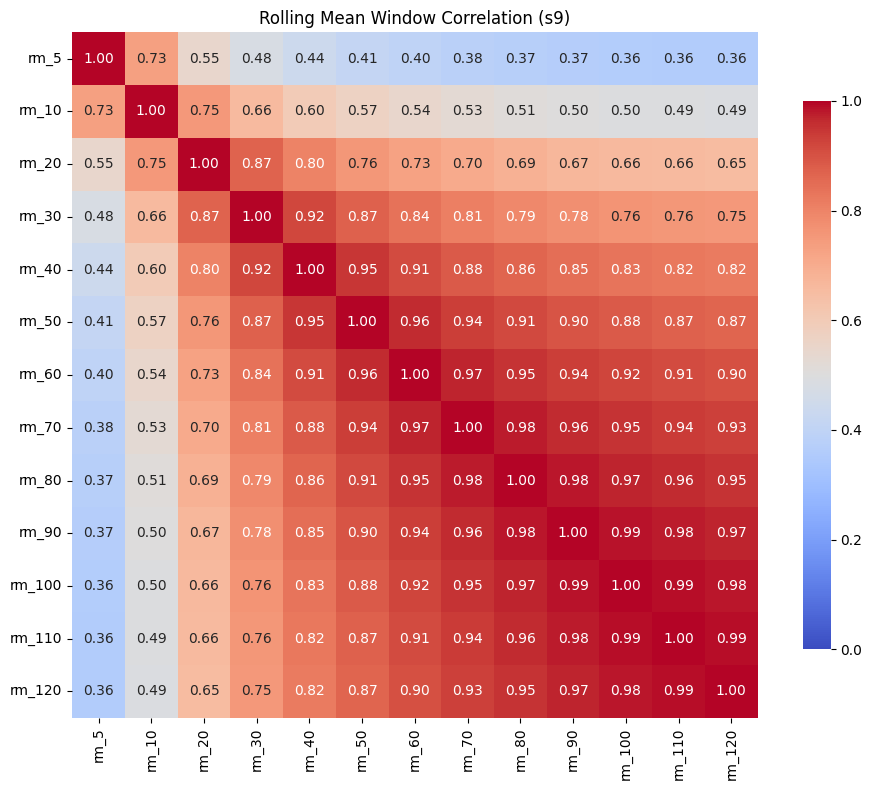

상관 0.95 이상 페어:
  rm_50 - rm_60: 0.962
  rm_60 - rm_70: 0.972
  rm_60 - rm_80: 0.952
  rm_70 - rm_80: 0.979
  rm_70 - rm_90: 0.963
  rm_70 - rm_100: 0.950
  rm_80 - rm_90: 0.984
  rm_80 - rm_100: 0.972
  rm_80 - rm_110: 0.961
  rm_80 - rm_120: 0.953
  rm_90 - rm_100: 0.987
  rm_90 - rm_110: 0.978
  rm_90 - rm_120: 0.969
  rm_100 - rm_110: 0.990
  rm_100 - rm_120: 0.982
  rm_110 - rm_120: 0.992


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 (네 경로에 맞게 수정)
cols = ['unit', 'cycle'] + [f'op{i}' for i in range(1,4)] + [f's{i}' for i in range(1,22)]
df = pd.read_csv('../../CMAPSSData/train_FD004.txt', sep=r'\s+', header=None, names=cols)

# 2. 분석 대상 센서
target_sensor = 's9'  # 다른 센서로 바꿔서 반복 가능

# 3. 윈도우 리스트
windows = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]

# 4. Rolling Mean 피처 생성
feat_df = pd.DataFrame()
for w in windows:
    feat_df[f'rm_{w}'] = (
        df.groupby('unit')[target_sensor]
          .transform(lambda x: x.rolling(w, min_periods=1).mean())
    )

# 5. 상관행렬
corr = feat_df.corr()

# 6. 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=0, vmax=1, square=True, cbar_kws={'shrink': 0.8})
plt.title(f'Rolling Mean Window Correlation ({target_sensor})')
plt.tight_layout()
plt.show()

# 7. 상관 0.95 이상인 페어 출력 (redundant 윈도우 찾기)
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if corr.iloc[i, j] > 0.95:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))
print("상관 0.95 이상 페어:")
for pair in high_corr:
    print(f"  {pair[0]} - {pair[1]}: {pair[2]:.3f}")

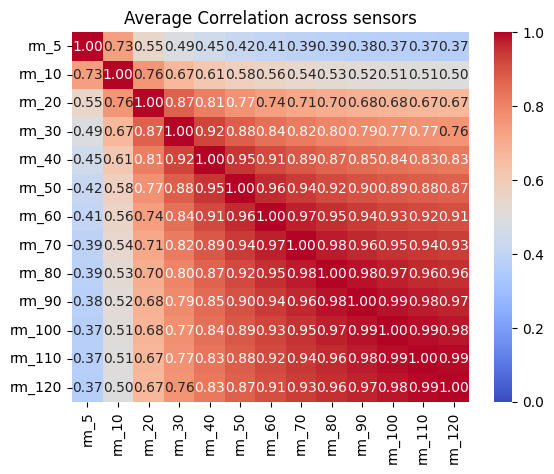

In [26]:
# 센서별로 corr 평균내기
sensors_to_check = ['s2', 's7', 's11', 's12', 's14', 's21']
all_corrs = []
for s in sensors_to_check:
    feat_df = pd.DataFrame()
    for w in windows:
        feat_df[f'rm_{w}'] = df.groupby('unit')[s].transform(
            lambda x: x.rolling(w, min_periods=1).mean())
    all_corrs.append(feat_df.corr())

avg_corr = sum(all_corrs) / len(all_corrs)
sns.heatmap(avg_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=0, vmax=1)
plt.title('Average Correlation across sensors')
plt.show()

## 6. 일반 실험 (기본 하이퍼파라미터)


 🏆 Ridge 평가 결과 (FD001)
 [Train] RMSE=12.0487 | MAE=8.8776 | R2=0.9085 | NASA=35239.1
 [Valid] RMSE=11.3905 | MAE=8.5218 | R2=0.9186 | NASA=7653.4
 [Test ] RMSE=16.6162 | MAE=12.9950 | R2=0.8401 | NASA=388.3


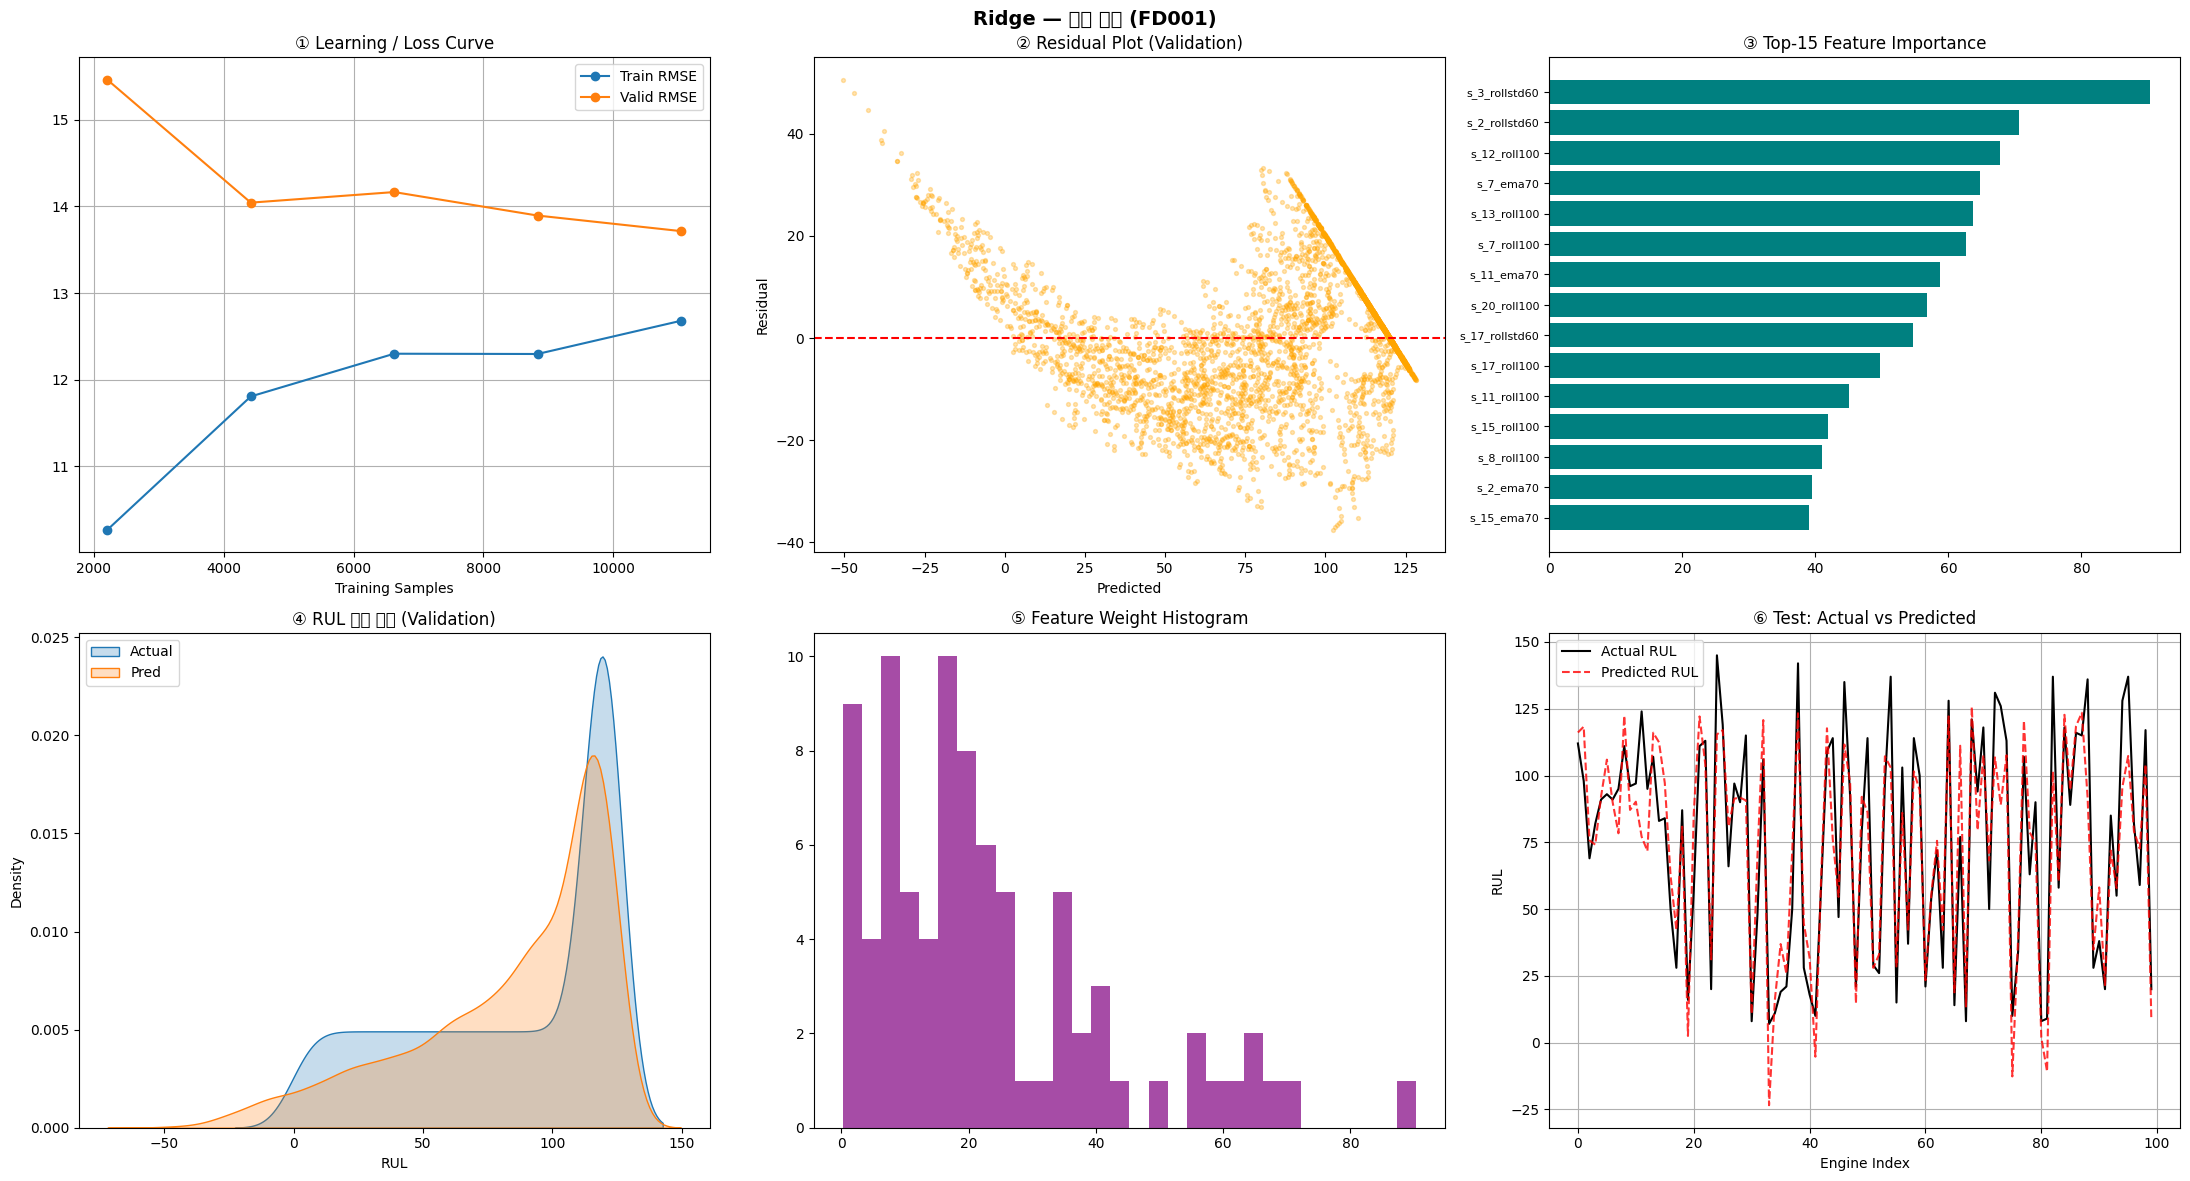

{'Train': {'RMSE': 12.048699169516972,
  'MAE': 8.877648374538065,
  'R2': 0.9085471892421536,
  'NASA_Score': 35239.1023983512},
 'Valid': {'RMSE': 11.390471280744608,
  'MAE': 8.521802710670189,
  'R2': 0.9185642239255171,
  'NASA_Score': 7653.371285668033},
 'Test': {'RMSE': 16.616198660663056,
  'MAE': 12.994989054037033,
  'R2': 0.8401164407951701,
  'NASA_Score': 388.26913110515756}}

In [27]:
# ── Ridge ─────────────────────────────────────────────────────────────────
ridge_params = {'alpha': 1.0, 'solver': 'auto', 'max_iter': 2000, 'random_state': RANDOM_STATE}
model_ridge  = Ridge(**ridge_params)
model_ridge.fit(X_train, y_train)
evaluate_full_pipeline(model_ridge, 'Ridge')



 🏆 Lasso 평가 결과 (FD001)
 [Train] RMSE=13.1443 | MAE=9.9294 | R2=0.8912 | NASA=41449.6
 [Valid] RMSE=12.0497 | MAE=9.2213 | R2=0.9089 | NASA=8294.1
 [Test ] RMSE=16.6503 | MAE=13.1997 | R2=0.8395 | NASA=371.8


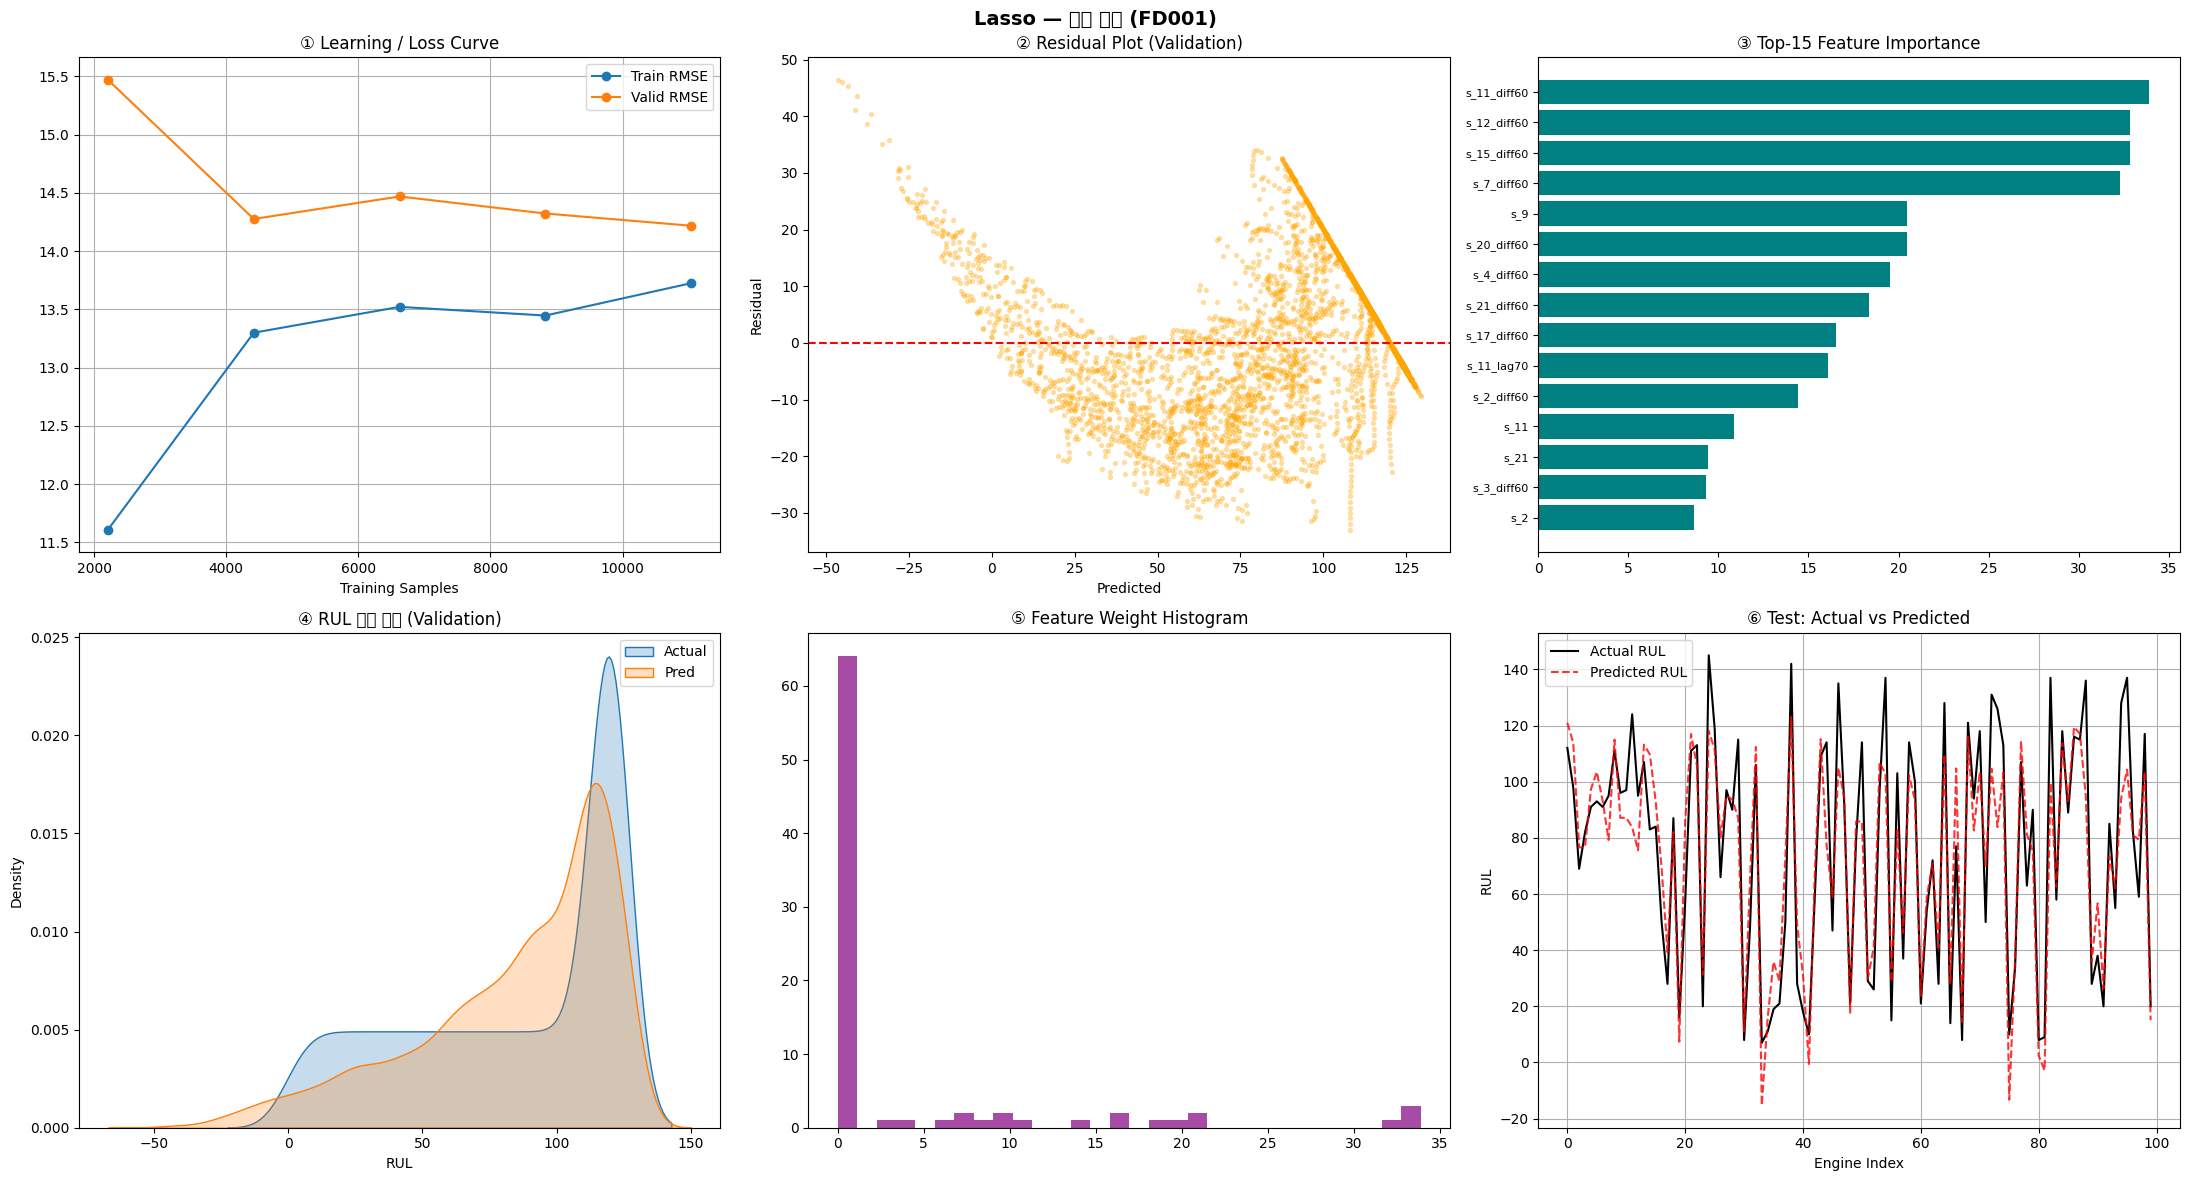

{'Train': {'RMSE': 13.144278779148213,
  'MAE': 9.929414811739965,
  'R2': 0.8911595675331079,
  'NASA_Score': 41449.55129835846},
 'Valid': {'RMSE': 12.049685740719001,
  'MAE': 9.221319220082188,
  'R2': 0.9088653995680265,
  'NASA_Score': 8294.081557306397},
 'Test': {'RMSE': 16.650334393995234,
  'MAE': 13.199665818911491,
  'R2': 0.839458847713886,
  'NASA_Score': 371.8243403796271}}

In [28]:
# ── Lasso ─────────────────────────────────────────────────────────────────
lasso_params = {'alpha': 0.1, 'max_iter': 2000, 'random_state': RANDOM_STATE}
model_lasso  = Lasso(**lasso_params)
model_lasso.fit(X_train, y_train)
evaluate_full_pipeline(model_lasso, 'Lasso')



 🏆 ElasticNet 평가 결과 (FD001)
 [Train] RMSE=15.4440 | MAE=12.1527 | R2=0.8497 | NASA=53887.9
 [Valid] RMSE=14.2025 | MAE=11.3195 | R2=0.8734 | NASA=10741.2
 [Test ] RMSE=18.9294 | MAE=15.2496 | R2=0.7925 | NASA=506.1


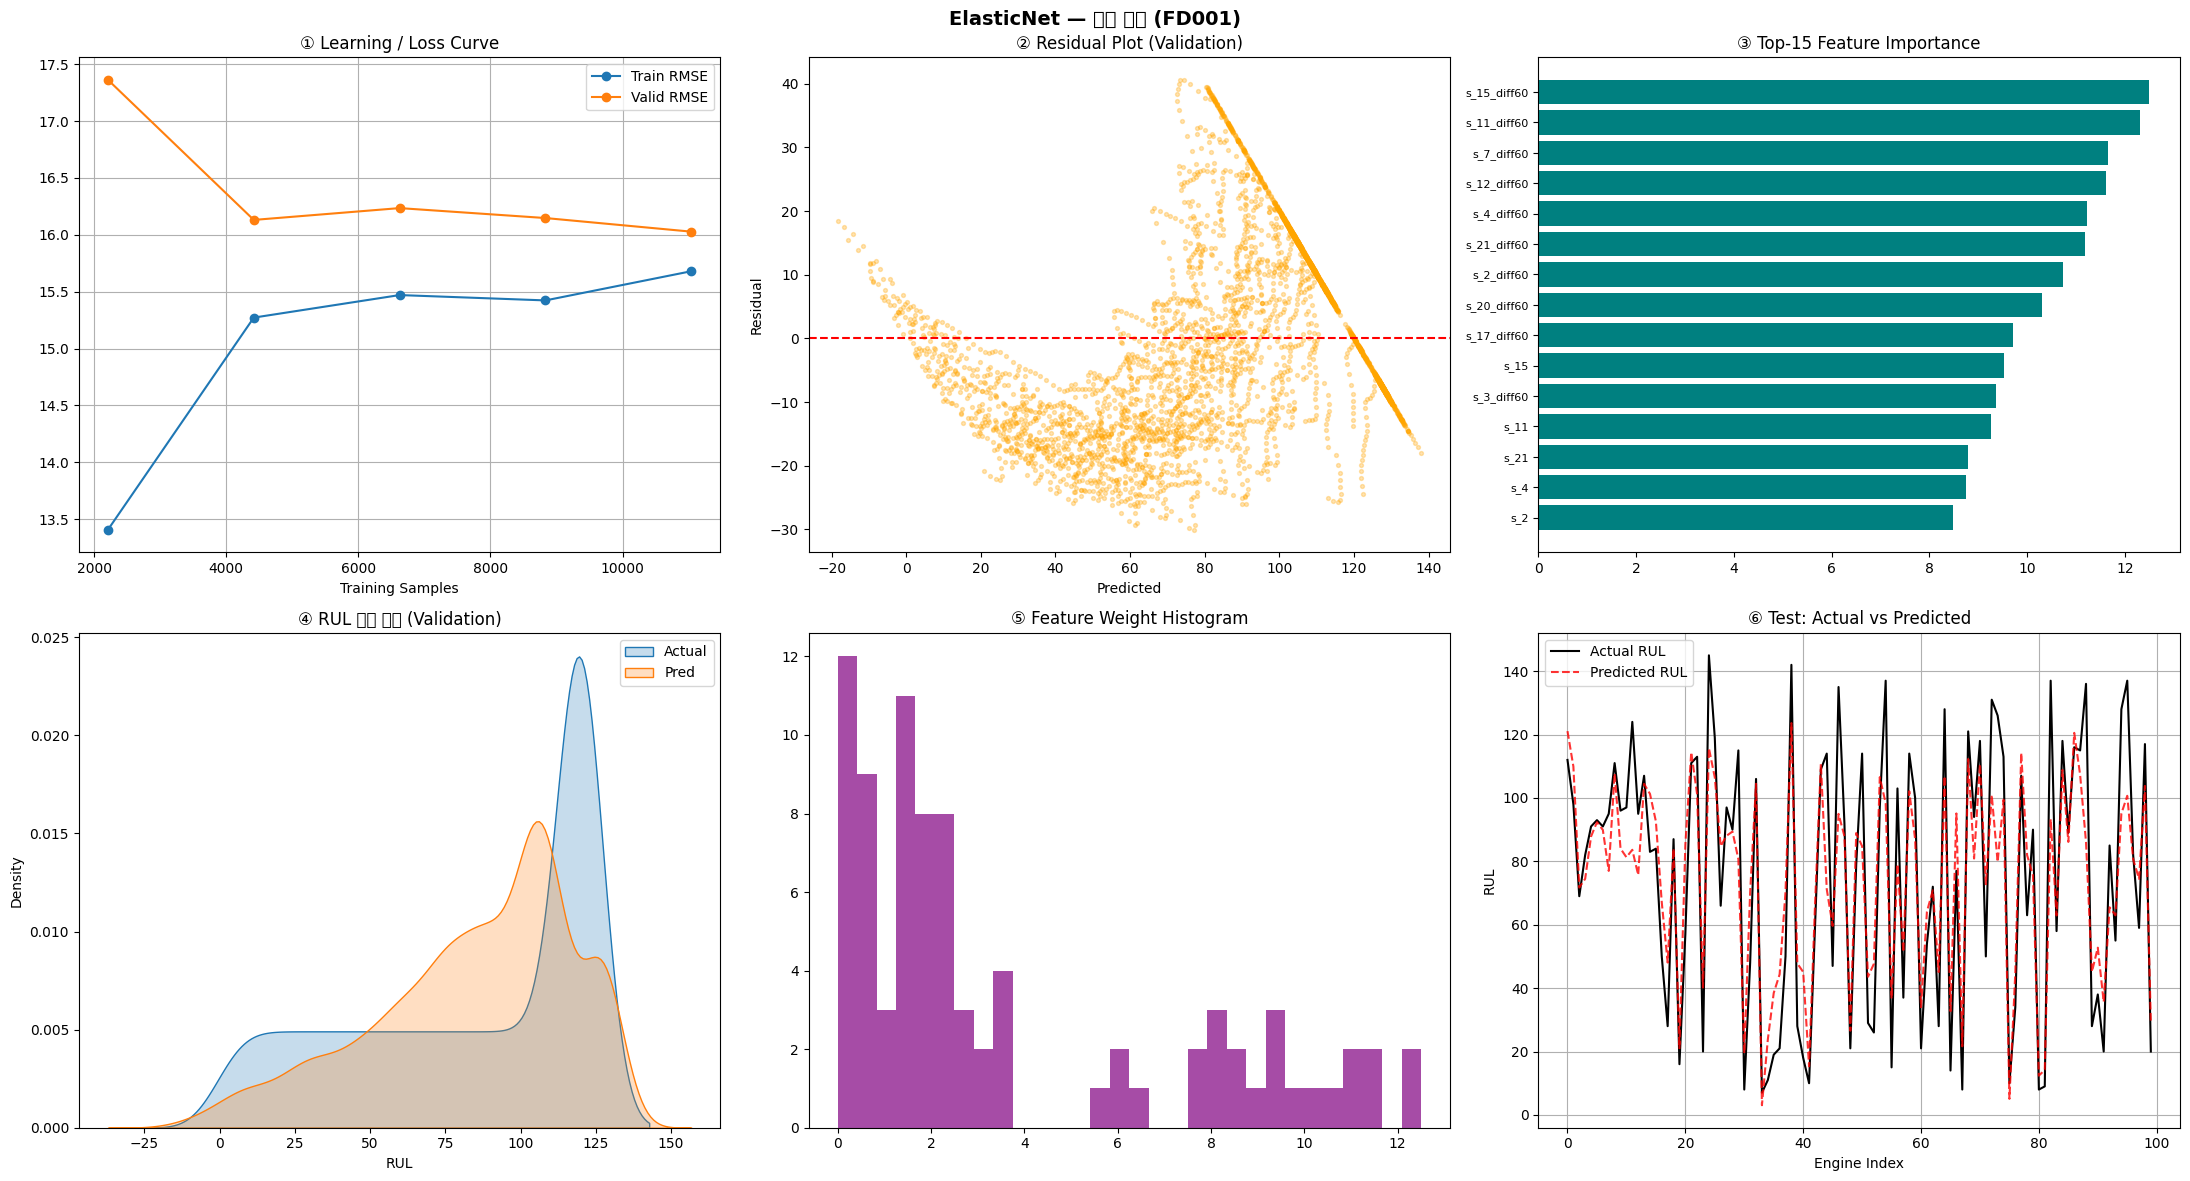

{'Train': {'RMSE': 15.443968139683538,
  'MAE': 12.15273520386217,
  'R2': 0.8497430636162808,
  'NASA_Score': 53887.85945421063},
 'Valid': {'RMSE': 14.202548492706613,
  'MAE': 11.3195154412742,
  'R2': 0.8733910478898353,
  'NASA_Score': 10741.184756271947},
 'Test': {'RMSE': 18.92942101941551,
  'MAE': 15.24957380513218,
  'R2': 0.7925014256257161,
  'NASA_Score': 506.13895635530815}}

In [29]:
# ── ElasticNet ────────────────────────────────────────────────────────────
elastic_params = {'alpha': 0.1, 'l1_ratio': 0.5, 'max_iter': 2000, 'random_state': RANDOM_STATE}
model_elastic  = ElasticNet(**elastic_params)
model_elastic.fit(X_train, y_train)
evaluate_full_pipeline(model_elastic, 'ElasticNet')



 🏆 RandomForest 평가 결과 (FD001)
 [Train] RMSE=4.6986 | MAE=3.0612 | R2=0.9861 | NASA=7132.0
 [Valid] RMSE=8.7386 | MAE=5.9413 | R2=0.9521 | NASA=5317.0
 [Test ] RMSE=13.2113 | MAE=10.0588 | R2=0.8989 | NASA=213.8


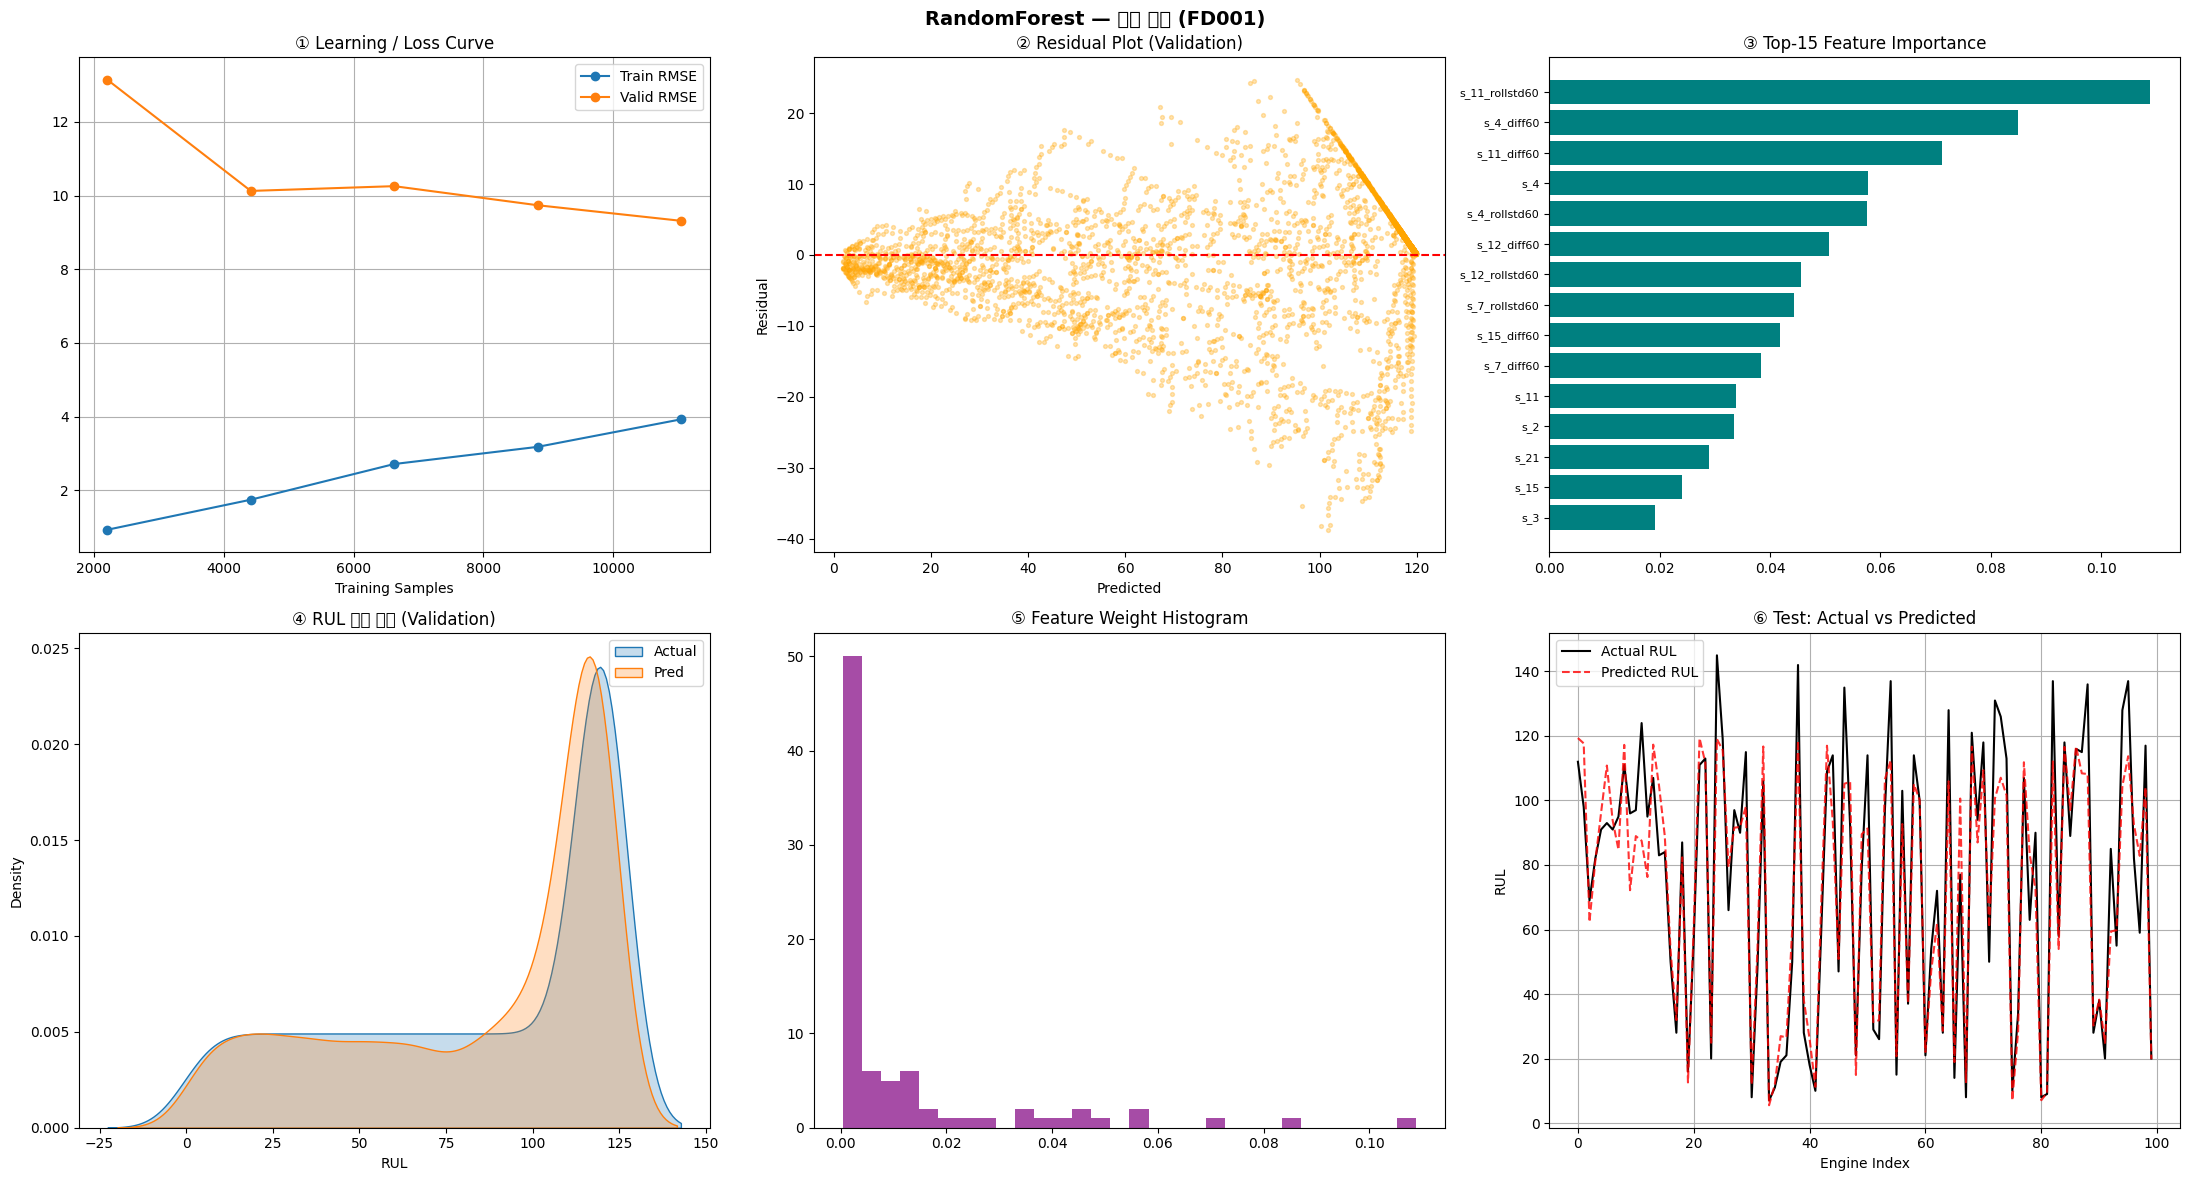

{'Train': {'RMSE': 4.69857045156912,
  'MAE': 3.061248106998317,
  'R2': 0.986092527112194,
  'NASA_Score': 7131.997919943655},
 'Valid': {'RMSE': 8.738595581719657,
  'MAE': 5.941347274802531,
  'R2': 0.9520691495945934,
  'NASA_Score': 5317.020302457118},
 'Test': {'RMSE': 13.211311256177485,
  'MAE': 10.058760091328896,
  'R2': 0.8989276636130475,
  'NASA_Score': 213.81271742806584}}

In [30]:
# ── Random Forest ─────────────────────────────────────────────────────────
rf_params = {
    'n_estimators': 200, 'max_depth': 10,
    'min_samples_split': 5, 'min_samples_leaf': 2,
    'max_features': 'sqrt', 'n_jobs': -1, 'random_state': RANDOM_STATE
}
model_rf = RandomForestRegressor(**rf_params)
model_rf.fit(X_train, y_train)
evaluate_full_pipeline(model_rf, 'RandomForest', is_tree=True)



 🏆 LightGBM (gpu) 평가 결과 (FD001)
 [Train] RMSE=3.0253 | MAE=1.9608 | R2=0.9942 | NASA=3664.7
 [Valid] RMSE=9.0866 | MAE=5.8559 | R2=0.9482 | NASA=6057.7
 [Test ] RMSE=13.0694 | MAE=9.9419 | R2=0.9011 | NASA=206.2


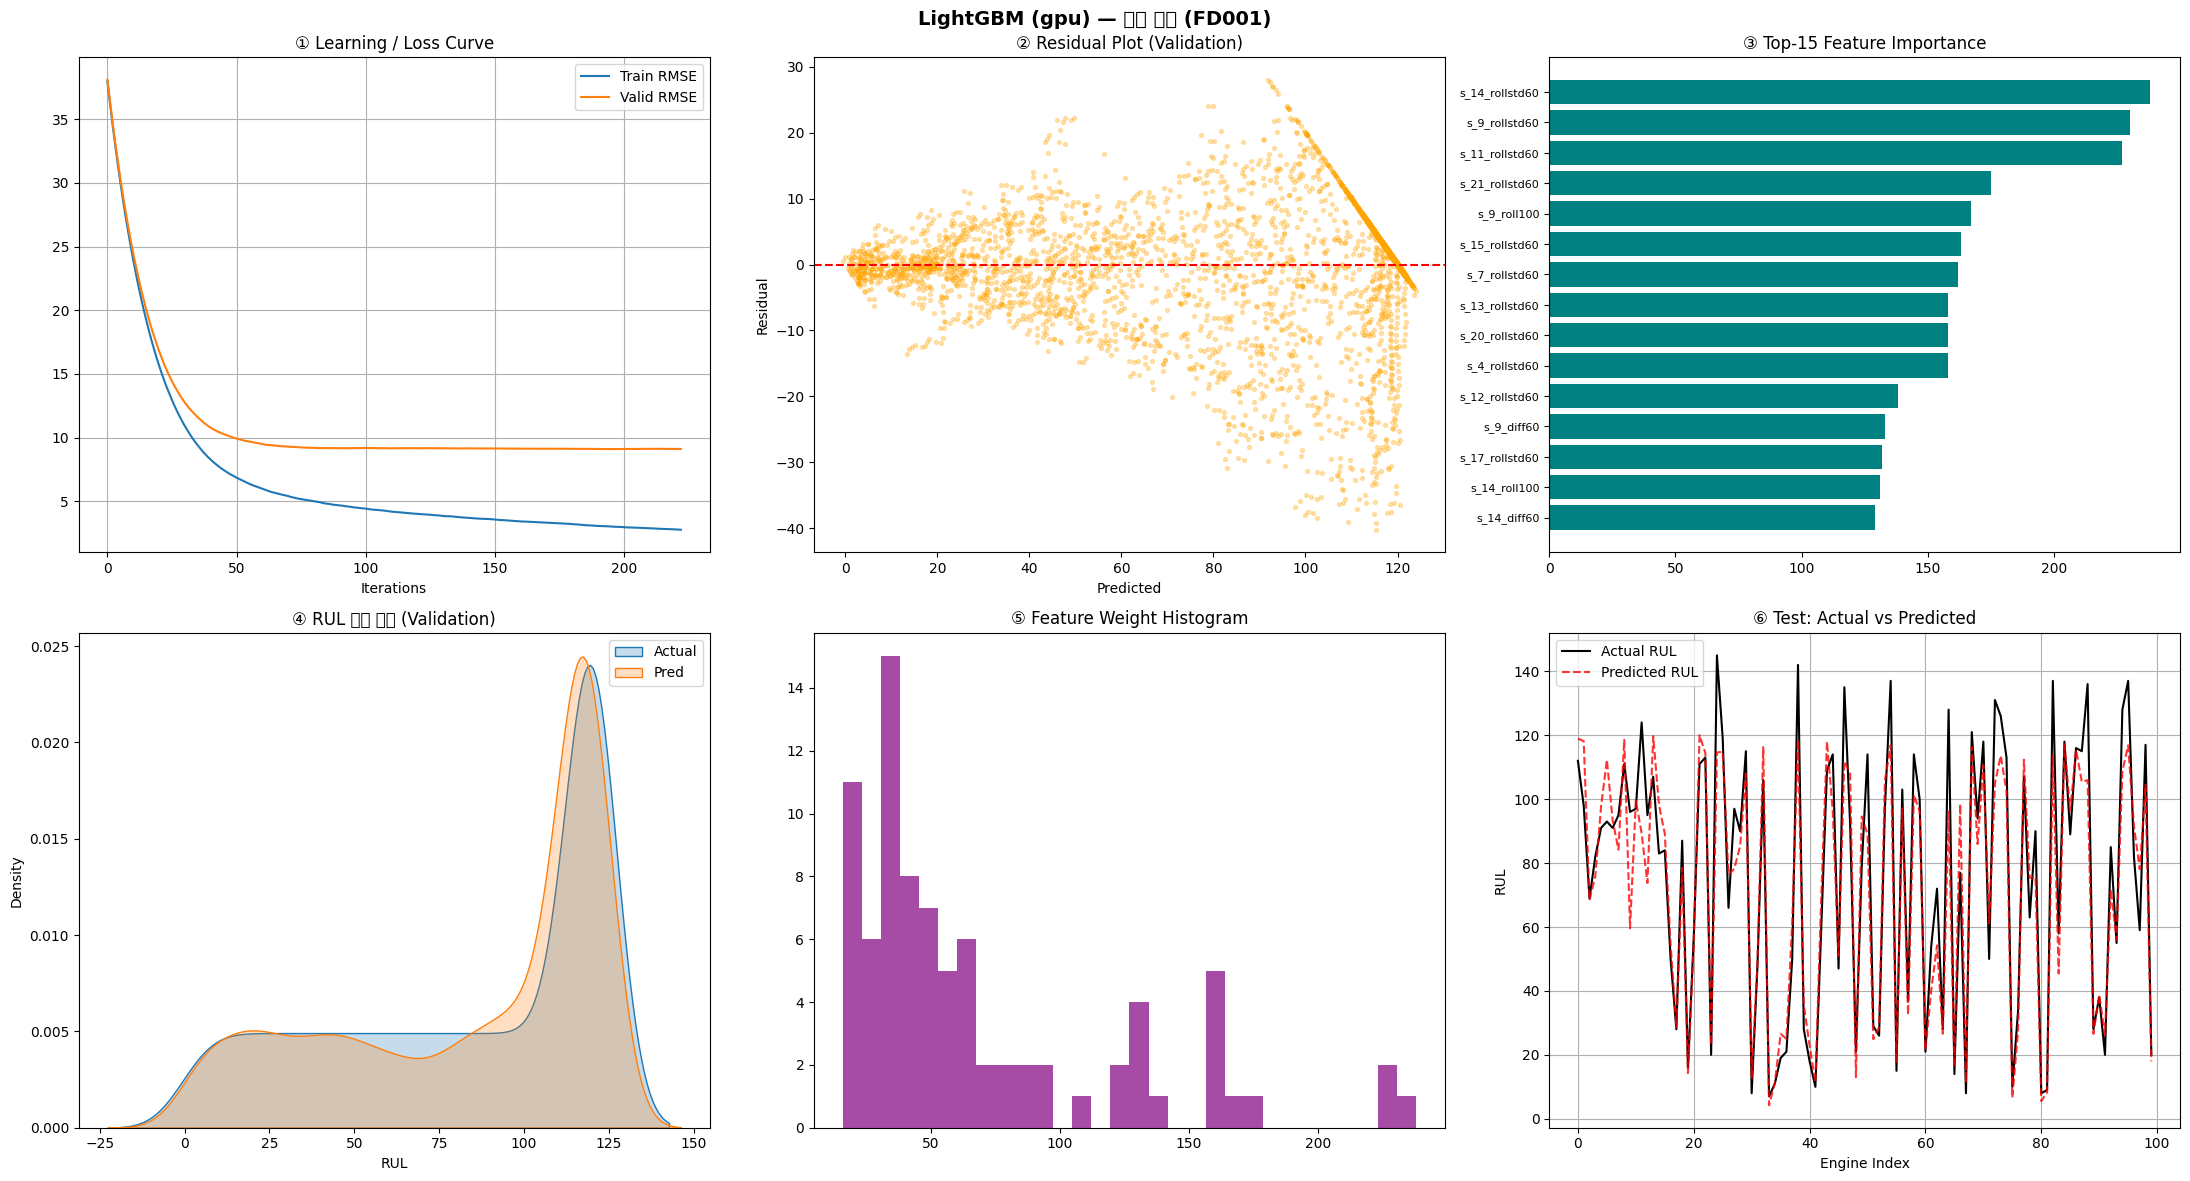

{'Train': {'RMSE': 3.025295663759691,
  'MAE': 1.9608491496299967,
  'R2': 0.9942342954339154,
  'NASA_Score': 3664.708234156495},
 'Valid': {'RMSE': 9.086636273181877,
  'MAE': 5.855880927150395,
  'R2': 0.948175139589583,
  'NASA_Score': 6057.715636449837},
 'Test': {'RMSE': 13.06943577564464,
  'MAE': 9.941928208309045,
  'R2': 0.9010868269997341,
  'NASA_Score': 206.19987414252031}}

In [31]:
# ── LightGBM ──────────────────────────────────────────────────────────────
lgb_params = {
    'n_estimators': 500, 'learning_rate': 0.05,
    'max_depth': 6, 'num_leaves': 31,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'reg_alpha': 0.1, 'reg_lambda': 1.0,
    'device': LGB_DEVICE,
    'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': -1
}
model_lgb = lgb.LGBMRegressor(**lgb_params)
model_lgb.fit(X_train, y_train,
              eval_set=[(X_train, y_train),(X_val, y_val)],
              eval_metric='rmse',
              callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])
res_lgb  = model_lgb.evals_result_
eval_dict_lgb = {'train': res_lgb['training']['rmse'],
                 'valid': res_lgb['valid_1']['rmse']}
evaluate_full_pipeline(model_lgb, f'LightGBM ({LGB_DEVICE})', is_tree=True, is_boosting=True, eval_results=eval_dict_lgb)



 🏆 XGBoost (cuda) 평가 결과 (FD001)
 [Train] RMSE=1.0144 | MAE=0.6613 | R2=0.9994 | NASA=1029.9
 [Valid] RMSE=9.2912 | MAE=5.9868 | R2=0.9458 | NASA=6356.7
 [Test ] RMSE=13.4871 | MAE=10.0502 | R2=0.8947 | NASA=222.6


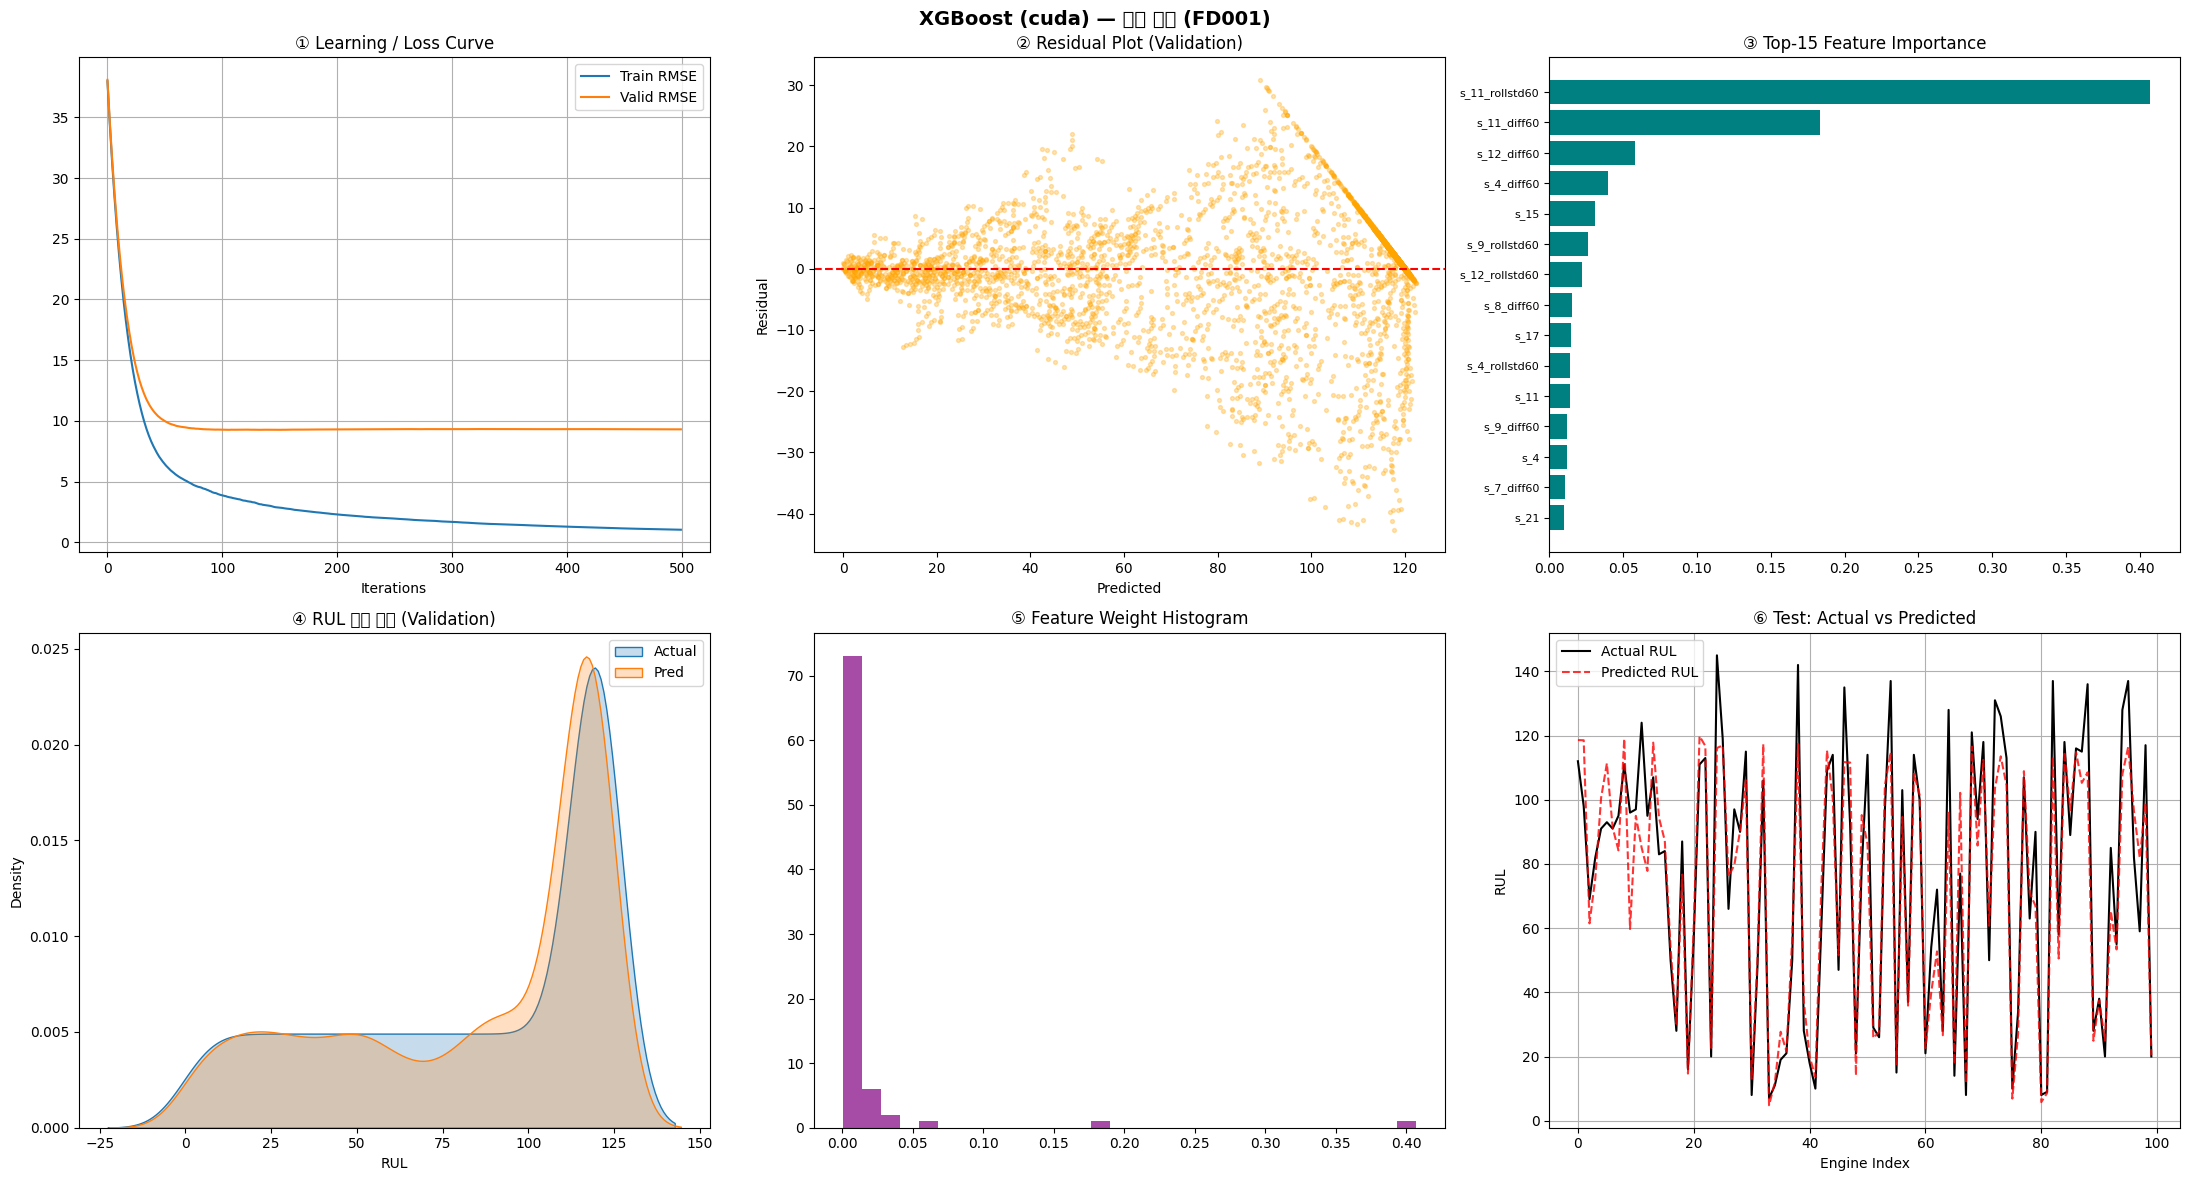

{'Train': {'RMSE': 1.014405909447802,
  'MAE': 0.6613128074276067,
  'R2': 0.9993517533565448,
  'NASA_Score': 1029.8566406634984},
 'Valid': {'RMSE': 9.291177829472263,
  'MAE': 5.986844597518884,
  'R2': 0.9458157086887219,
  'NASA_Score': 6356.735671550399},
 'Test': {'RMSE': 13.487098412177541,
  'MAE': 10.050168418884278,
  'R2': 0.8946638335750644,
  'NASA_Score': 222.5837453939356}}

In [32]:
# ── XGBoost ───────────────────────────────────────────────────────────────
xgb_params = {
    'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 6,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'reg_alpha': 0.1, 'reg_lambda': 1.0,
    'tree_method': 'hist', 'device': XGB_DEVICE,
    'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': 0
}
model_xgb = xgb.XGBRegressor(**xgb_params)
model_xgb.fit(X_train, y_train,
              eval_set=[(X_train, y_train),(X_val, y_val)], verbose=False)
res_xgb = model_xgb.evals_result()
eval_dict_xgb = {'train': res_xgb['validation_0']['rmse'],
                 'valid': res_xgb['validation_1']['rmse']}
evaluate_full_pipeline(model_xgb, f'XGBoost ({XGB_DEVICE})', is_tree=True, is_boosting=True, eval_results=eval_dict_xgb)


In [33]:
# === 누수 진단: 예측 잔차 분석 ===
for mname, m in [('Ridge', model_ridge), ('LGBM', model_lgb), ('XGB', model_xgb)]:
    pred = np.clip(m.predict(X_test), 0, CONFIG['rul_cap'])
    d = pred - y_test
    print(f'\n[{mname}] pred: min={pred.min():.1f} max={pred.max():.1f} mean={pred.mean():.1f}')
    print(f'         잔차 음수(보수적): {(d<0).mean():.1%}')
    print(f'         잔차 양수(낙관적): {(d>0).mean():.1%}')
    print(f'         |d| 평균: {np.abs(d).mean():.2f}')

# 음수 비율이 70% 이상이면 정상적으로 잘 나온 거. 50:50인데 NASA가 200대면 누수


[Ridge] pred: min=0.0 max=120.0 mean=73.9
         잔차 음수(보수적): 45.0%
         잔차 양수(낙관적): 55.0%
         |d| 평균: 12.99

[LGBM] pred: min=4.2 max=120.0 mean=72.6
         잔차 음수(보수적): 53.0%
         잔차 양수(낙관적): 47.0%
         |d| 평균: 9.94

[XGB] pred: min=4.8 max=119.8 mean=72.5
         잔차 음수(보수적): 52.0%
         잔차 양수(낙관적): 48.0%
         |d| 평균: 10.05


# 모델 저장 pkl

## 7. Optuna 튜닝 설정

In [35]:
# ============================================================
# ⚙️ OPTUNA 설정
# ============================================================
N_TRIALS_LIN    = 30      # 선형 모델
N_TRIALS_TREE   = 50      # 트리 모델
OPTUNA_METRIC   = 'rmse'  # 'rmse' | 'nasa'
N_SPLITS        = 5       # GroupKFold
INNER_VAL_RATIO = 0.15    # ES용 inner-val 비율

groups = train_ml['unit_nr'].values
gkf    = GroupKFold(n_splits=N_SPLITS)

ALL_RESULTS = {}
BEST_MODELS = {}

# ── 헬퍼 ──────────────────────────────────────────────────────────────────
def clip_rul(pred, cap=CONFIG['rul_cap']):
    return np.clip(pred, 0, cap)

def cv_score(builder, X, y, grp, metric=OPTUNA_METRIC):
    rmse_list, nasa_list = [], []
    for ti, vi in gkf.split(X, y, grp):
        m = builder()
        m.fit(X.iloc[ti], y.iloc[ti])
        pred = clip_rul(m.predict(X.iloc[vi]))
        rmse_list.append(float(np.sqrt(mean_squared_error(y.iloc[vi], pred))))
        nasa_list.append(float(calculate_nasa_score(y.iloc[vi], pred) / max(len(y.iloc[vi]), 1)))
    return {'cv_rmse_mean': float(np.mean(rmse_list)), 'cv_nasa_mean': float(np.mean(nasa_list))}

def _inner_split(X, y, grp, val_ratio=INNER_VAL_RATIO, seed=RANDOM_STATE):
    rng   = np.random.default_rng(seed)
    units = np.array(sorted(set(grp)))
    rng.shuffle(units)
    n_va  = max(1, int(len(units) * val_ratio))
    va_set = set(units[:n_va])
    mask   = np.array([g in va_set for g in grp])
    return X[~mask], y[~mask], X[mask], y[mask]

def _fit_with_es(model, name, Xtr, ytr, Xva=None, yva=None):
    if name == 'RandomForest' or Xva is None:
        model.fit(Xtr, ytr)
    elif name == 'XGBoost':
        model.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    elif name == 'LightGBM':
        model.fit(Xtr, ytr, eval_set=[(Xva, yva)],
                  callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])

def cv_score_es(builder, X, y, grp, name, metric=OPTUNA_METRIC):
    rmse_list, nasa_list = [], []
    for ti, vi in gkf.split(X, y, grp):
        Xtr_f = X.iloc[ti]; ytr_f = y.iloc[ti]
        Xva   = X.iloc[vi]; yva   = y.iloc[vi]
        model = builder()
        if name in ('XGBoost', 'LightGBM'):
            X_in, y_in, X_iv, y_iv = _inner_split(
                Xtr_f.values, ytr_f.values, grp[ti])
            X_in = pd.DataFrame(X_in, columns=X.columns)
            X_iv = pd.DataFrame(X_iv, columns=X.columns)
            _fit_with_es(model, name, X_in, pd.Series(y_in), X_iv, pd.Series(y_iv))
        else:
            _fit_with_es(model, name, Xtr_f, ytr_f)
        pred = clip_rul(model.predict(Xva))
        rmse_list.append(float(np.sqrt(mean_squared_error(yva, pred))))
        nasa_list.append(float(calculate_nasa_score(yva, pred) / max(len(yva), 1)))
    return {'cv_rmse_mean': float(np.mean(rmse_list)),
            'cv_rmse_std' : float(np.std(rmse_list)),
            'cv_nasa_mean': float(np.mean(nasa_list))}

print('✅ Optuna 설정 완료')
print(f'   N_TRIALS: 선형={N_TRIALS_LIN} / 트리={N_TRIALS_TREE}')
print(f'   Metric  : {OPTUNA_METRIC.upper()} | CV splits: {N_SPLITS}')


✅ Optuna 설정 완료
   N_TRIALS: 선형=30 / 트리=50
   Metric  : RMSE | CV splits: 5


## 8. Optuna — 선형 모델 (Ridge / Lasso / ElasticNet)

In [36]:
def _build_linear(trial, name):
    if name == 'Ridge':
        return Ridge(alpha=trial.suggest_float('alpha', 0.01, 500, log=True),
                     solver=trial.suggest_categorical('solver', ['auto','svd','cholesky','lsqr']),
                     max_iter=3000, random_state=RANDOM_STATE)
    elif name == 'Lasso':
        return Lasso(alpha=trial.suggest_float('alpha', 1e-4, 10, log=True),
                     selection=trial.suggest_categorical('selection', ['cyclic','random']),
                     max_iter=3000, tol=0.001, random_state=RANDOM_STATE)
    elif name == 'ElasticNet':
        return ElasticNet(alpha=trial.suggest_float('alpha', 1e-4, 10, log=True),
                          l1_ratio=trial.suggest_float('l1_ratio', 0.05, 0.95),
                          selection=trial.suggest_categorical('selection', ['cyclic','random']),
                          max_iter=3000, tol=0.001, random_state=RANDOM_STATE)
    raise ValueError(name)

for mname in ['Ridge', 'Lasso', 'ElasticNet']:
    t0 = time.time()
    print(f'[{mname}] 최적화 시작 ... ({N_TRIALS_LIN} trials)', end='', flush=True)

    def _obj_lin(trial, _m=mname):
        res = cv_score(lambda: _build_linear(trial, _m), X_train, y_train, groups)
        return res['cv_nasa_mean'] if OPTUNA_METRIC == 'nasa' else res['cv_rmse_mean']

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(_obj_lin, n_trials=N_TRIALS_LIN, show_progress_bar=False)

    best_p = study.best_params
    best_m = _build_linear(optuna.trial.FixedTrial(best_p), mname)
    best_m.fit(X_train, y_train)

    cv_res    = cv_score(lambda: _build_linear(optuna.trial.FixedTrial(best_p), mname),
                         X_train, y_train, groups)
    val_mets  = get_metrics(y_val,  best_m.predict(X_val))
    test_mets = get_metrics(y_test, best_m.predict(X_test))

    ALL_RESULTS[mname] = {
        'type':'linear', 'model':best_m, 'params':best_p,
        'cv_rmse':cv_res['cv_rmse_mean'], 'cv_nasa':cv_res['cv_nasa_mean'],
        'val_metrics':val_mets, 'test_metrics':test_mets, 'fit_seconds':time.time()-t0
    }
    BEST_MODELS[mname] = best_m

    print(f'  ✅ | CV RMSE={cv_res["cv_rmse_mean"]:.3f} '
          f'| Val RMSE={val_mets["RMSE"]:.3f} '
          f'| Test NASA={test_mets["NASA_Score"]:.1f} '
          f'| {time.time()-t0:.0f}s')
    print(f'   best_params: {best_p}')

print('\n✅ 선형 모델 최적화 완료')


[Ridge] 최적화 시작 ... (30 trials)  ✅ | CV RMSE=12.727 | Val RMSE=11.372 | Test NASA=386.8 | 7s
   best_params: {'alpha': 1.3857298612350635, 'solver': 'auto'}
[Lasso] 최적화 시작 ... (30 trials)  ✅ | CV RMSE=12.811 | Val RMSE=11.521 | Test NASA=387.7 | 4338s
   best_params: {'alpha': 0.004550798143438569, 'selection': 'cyclic'}
[ElasticNet] 최적화 시작 ... (30 trials)  ✅ | CV RMSE=12.728 | Val RMSE=11.367 | Test NASA=386.1 | 2196s
   best_params: {'alpha': 0.00015117443002840783, 'l1_ratio': 0.3619672221642006, 'selection': 'random'}

✅ 선형 모델 최적화 완료


## 9. Optuna — RandomForest (CPU)

In [37]:
def _build_rf(trial):
    return RandomForestRegressor(
        n_estimators      = trial.suggest_int  ('n_estimators',    100, 600),
        max_depth         = trial.suggest_int  ('max_depth',         5,  30),
        min_samples_split = trial.suggest_int  ('min_samples_split', 2,  20),
        min_samples_leaf  = trial.suggest_int  ('min_samples_leaf',  1,  10),
        max_features      = trial.suggest_float('max_features',     0.2, 1.0),
        random_state=RANDOM_STATE, n_jobs=-1)

t0 = time.time()
print(f'[RandomForest] 최적화 시작 ... ({N_TRIALS_TREE} trials)')

study_rf = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
study_rf.optimize(
    lambda t: cv_score_es(lambda: _build_rf(t), X_train, y_train, groups, 'RandomForest')
             ['cv_nasa_mean' if OPTUNA_METRIC=='nasa' else 'cv_rmse_mean'],
    n_trials=N_TRIALS_TREE, show_progress_bar=False)

best_p = study_rf.best_params
best_m = _build_rf(optuna.trial.FixedTrial(best_p))
best_m.fit(X_train, y_train)

cv_res    = cv_score_es(lambda: _build_rf(optuna.trial.FixedTrial(best_p)),
                         X_train, y_train, groups, 'RandomForest')
val_mets  = get_metrics(y_val,  best_m.predict(X_val))
test_mets = get_metrics(y_test, best_m.predict(X_test))

ALL_RESULTS['RandomForest'] = {
    'type':'tree', 'model':best_m, 'params':best_p,
    'cv_rmse':cv_res['cv_rmse_mean'], 'cv_rmse_std':cv_res['cv_rmse_std'],
    'cv_nasa':cv_res['cv_nasa_mean'],
    'val_metrics':val_mets, 'test_metrics':test_mets, 'fit_seconds':time.time()-t0
}
BEST_MODELS['RandomForest'] = best_m

print(f'  ✅ | CV RMSE={cv_res["cv_rmse_mean"]:.3f} | Val RMSE={val_mets["RMSE"]:.3f} '
      f'| Test NASA={test_mets["NASA_Score"]:.1f} | {time.time()-t0:.0f}s')
print(f'   best_params: {best_p}')


[RandomForest] 최적화 시작 ... (50 trials)
  ✅ | CV RMSE=8.905 | Val RMSE=8.997 | Test NASA=208.1 | 866s
   best_params: {'n_estimators': 273, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 8, 'max_features': 0.2883857837507547}


## 10. Optuna — XGBoost / LightGBM (GPU 자동)

In [38]:
def _build_boost(trial, name):
    if name == 'XGBoost':
        return xgb.XGBRegressor(
            n_estimators          = trial.suggest_int  ('n_estimators',     150, 700),
            max_depth             = trial.suggest_int  ('max_depth',          3,  10),
            learning_rate         = trial.suggest_float('learning_rate',   0.01, 0.3,  log=True),
            subsample             = trial.suggest_float('subsample',        0.5, 1.0),
            colsample_bytree      = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            reg_alpha             = trial.suggest_float('reg_alpha',       1e-8,  10,  log=True),
            reg_lambda            = trial.suggest_float('reg_lambda',      1e-8,  10,  log=True),
            early_stopping_rounds = 30,
            tree_method='hist', device=XGB_DEVICE,
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    elif name == 'LightGBM':
        return lgb.LGBMRegressor(
            n_estimators     = trial.suggest_int  ('n_estimators',    150, 700),
            max_depth        = trial.suggest_int  ('max_depth',         3,  12),
            learning_rate    = trial.suggest_float('learning_rate',  0.01, 0.3,  log=True),
            num_leaves       = trial.suggest_int  ('num_leaves',       15, 255),
            subsample        = trial.suggest_float('subsample',       0.5, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree',0.5, 1.0),
            reg_alpha        = trial.suggest_float('reg_alpha',      1e-8,  10,  log=True),
            reg_lambda       = trial.suggest_float('reg_lambda',     1e-8,  10,  log=True),
            device=LGB_DEVICE, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)
    raise ValueError(name)

for mname in ['XGBoost', 'LightGBM']:
    t0  = time.time()
    dev = XGB_DEVICE if mname == 'XGBoost' else LGB_DEVICE
    print(f'[{mname}] 최적화 시작 ... ({N_TRIALS_TREE} trials) | device={dev}')

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(
        lambda t, _m=mname: cv_score_es(lambda: _build_boost(t, _m), X_train, y_train, groups, _m)
                            ['cv_nasa_mean' if OPTUNA_METRIC=='nasa' else 'cv_rmse_mean'],
        n_trials=N_TRIALS_TREE, show_progress_bar=False)

    best_p = study.best_params
    best_m = _build_boost(optuna.trial.FixedTrial(best_p), mname)

    X_in, y_in, X_iv, y_iv = _inner_split(X_train.values, y_train.values, groups)
    X_in = pd.DataFrame(X_in, columns=ML_FEATURES)
    X_iv = pd.DataFrame(X_iv, columns=ML_FEATURES)
    _fit_with_es(best_m, mname, X_in, pd.Series(y_in), X_iv, pd.Series(y_iv))

    cv_res    = cv_score_es(lambda: _build_boost(optuna.trial.FixedTrial(best_p), mname),
                             X_train, y_train, groups, mname)
    val_mets  = get_metrics(y_val,  best_m.predict(X_val))
    test_mets = get_metrics(y_test, best_m.predict(X_test))

    ALL_RESULTS[mname] = {
        'type':'tree', 'model':best_m, 'params':best_p,
        'cv_rmse':cv_res['cv_rmse_mean'], 'cv_rmse_std':cv_res['cv_rmse_std'],
        'cv_nasa':cv_res['cv_nasa_mean'],
        'val_metrics':val_mets, 'test_metrics':test_mets, 'fit_seconds':time.time()-t0
    }
    BEST_MODELS[mname] = best_m

    print(f'  ✅ | CV RMSE={cv_res["cv_rmse_mean"]:.3f}±{cv_res["cv_rmse_std"]:.3f} '
          f'| Val RMSE={val_mets["RMSE"]:.3f} '
          f'| Test NASA={test_mets["NASA_Score"]:.1f} '
          f'| {time.time()-t0:.0f}s')
    print(f'   best_params: {best_p}')

print('\n✅ Boosting 모델 최적화 완료')


[XGBoost] 최적화 시작 ... (50 trials) | device=cuda
  ✅ | CV RMSE=9.059±0.566 | Val RMSE=8.764 | Test NASA=197.2 | 219s
   best_params: {'n_estimators': 582, 'max_depth': 5, 'learning_rate': 0.03055494656963408, 'subsample': 0.5139388480023126, 'colsample_bytree': 0.575052134881134, 'reg_alpha': 0.0004044245542090905, 'reg_lambda': 0.006131977289987194}
[LightGBM] 최적화 시작 ... (50 trials) | device=gpu
  ✅ | CV RMSE=9.171±0.525 | Val RMSE=8.767 | Test NASA=185.1 | 535s
   best_params: {'n_estimators': 321, 'max_depth': 6, 'learning_rate': 0.02753128686408985, 'num_leaves': 107, 'subsample': 0.8265015800721066, 'colsample_bytree': 0.5038788416660758, 'reg_alpha': 0.0001653282123997987, 'reg_lambda': 4.6763069620690654e-06}

✅ Boosting 모델 최적화 완료


## 11. 전체 모델 비교표

In [39]:
rows = []
for mname, res in ALL_RESULTS.items():
    rows.append({
        'Model'    : mname,
        'CV_RMSE'  : round(res['cv_rmse'], 4),
        'Val_RMSE' : round(res['val_metrics']['RMSE'], 4),
        'Val_NASA' : round(res['val_metrics']['NASA_Score'], 1),
        'Test_RMSE': round(res['test_metrics']['RMSE'], 4),
        'Test_NASA': round(res['test_metrics']['NASA_Score'], 1),
        'Test_R2'  : round(res['test_metrics']['R2'], 4),
        'Time(s)'  : round(res['fit_seconds'], 1),
    })

summary_df = pd.DataFrame(rows).sort_values('Test_RMSE').reset_index(drop=True)
print('\n' + '='*70)
print('📊 모델 성능 비교표 — FD003 (Test RMSE 기준 정렬)')
print('='*70)
print(summary_df.to_string(index=False))
print('='*70)

best_name = summary_df.iloc[0]['Model']
print(f'\n🏆 최고 성능 모델: {best_name}')
print(f'   Test RMSE  = {summary_df.iloc[0]["Test_RMSE"]}')
print(f'   Test NASA  = {summary_df.iloc[0]["Test_NASA"]}')
print(f'   Test R²    = {summary_df.iloc[0]["Test_R2"]}')



📊 모델 성능 비교표 — FD003 (Test RMSE 기준 정렬)
       Model  CV_RMSE  Val_RMSE  Val_NASA  Test_RMSE  Test_NASA  Test_R2  Time(s)
    LightGBM   9.1714    8.7674    5684.6    12.4226      185.1   0.9106    534.5
     XGBoost   9.0592    8.7637    5542.4    12.6777      197.2   0.9069    219.1
RandomForest   8.9052    8.9969    5978.7    12.9688      208.1   0.9026    865.8
       Lasso  12.8108   11.5208    7820.5    16.6117      387.7   0.8402   4337.5
  ElasticNet  12.7282   11.3672    7609.0    16.6117      386.1   0.8402   2196.3
       Ridge  12.7271   11.3720    7619.4    16.6127      386.8   0.8402      7.5

🏆 최고 성능 모델: LightGBM
   Test RMSE  = 12.4226
   Test NASA  = 185.1
   Test R²    = 0.9106


In [41]:
import pickle 
import os

# 1. 저장 폴더 생성
save_dir = 'saved_models'
os.makedirs(save_dir, exist_ok=True)

# 2. 전처리 에셋 저장 (필수)
preprocess_assets = {
    'op_scaler': data.get('op_scaler'),
    'kmeans': data.get('kmeans'),
    'scalers': data.get('scalers'),
    'useful_sensors': data.get('useful_sensors'),
    'ml_features': data.get('ml_features'),
    'ohe_cols': data.get('ohe_cols'),
    'config': CONFIG
}

# 파일 확장자를 .pkl로 변경
preprocess_filename = f"{save_dir}/preprocess_{CONFIG['subset']}.pkl"

# pickle.dump를 사용하여 저장 (wb: 쓰기/바이너리 모드 필수)
with open(preprocess_filename, 'wb') as f:
    pickle.dump(preprocess_assets, f)
print(f"✅ [전처리] {CONFIG['subset']} 에셋 저장 완료 (.pkl)")

# 3. 모델 통합 저장 루프
models_to_save = [
    ('model_xgb', 'XGBoost'),
    ('model_lgb', 'LightGBM'),
    ('model_rf',  'RF'),
    ('model_ridge','Ridge'),
    ('model_lasso','Lasso'),
    ('model_enet', 'ElasticNet')
]

print("-" * 30)
for var_name, model_label in models_to_save:
    if var_name in globals() and globals()[var_name] is not None:
        model_obj = globals()[var_name]
        # 파일 확장자 .pkl로 변경
        save_path = f"{save_dir}/model_{model_label}_{CONFIG['subset']}.pkl"
        
        # 바이너리 모드로 파일 열기 후 저장
        with open(save_path, 'wb') as f:
            pickle.dump(model_obj, f)
        print(f"✅ [모델] {model_label} 저장 성공: {save_path}")
    else:
        pass
print("-" * 30)
print("🚀 모든 가용 자산 저장 프로세스 종료")

✅ [전처리] FD001 에셋 저장 완료 (.pkl)
------------------------------
✅ [모델] XGBoost 저장 성공: saved_models/model_XGBoost_FD001.pkl
✅ [모델] LightGBM 저장 성공: saved_models/model_LightGBM_FD001.pkl
✅ [모델] RF 저장 성공: saved_models/model_RF_FD001.pkl
✅ [모델] Ridge 저장 성공: saved_models/model_Ridge_FD001.pkl
✅ [모델] Lasso 저장 성공: saved_models/model_Lasso_FD001.pkl
------------------------------
🚀 모든 가용 자산 저장 프로세스 종료


In [42]:
## 체크 2 & 3
# 실제 존재하는 센서 컬럼 하나를 자동으로 선택
existing_sensors = [col for col in test_ml.columns if 's_' in col and 'lag' not in col and 'roll' not in col]
target_s = existing_sensors[0] if existing_sensors else 'sensor_column_name'

# 해당 센서의 lag와 roll 컬럼 찾기
lag_col = [col for col in test_ml.columns if f'{target_s}_lag' in col][0]
roll_col = [col for col in test_ml.columns if f'{target_s}_roll' in col][0]

u = test_ml[test_ml['unit_nr'] == 1]

print(f"--- {target_s} 기반 시계열 체크 ---")
display(u[['time_cycles', target_s, lag_col]].head(10)) # 체크 2
display(u[[target_s, roll_col]].tail())                # 체크 3

--- s_2 기반 시계열 체크 ---


,time_cycles,s_2,s_2_lag70
0,1,0.393127,0.0
1,2,0.336426,0.0
2,3,0.295288,0.0
3,4,0.270386,0.0
4,5,0.252960,0.0
5,6,0.235748,0.0
6,7,0.217590,0.0
7,8,0.200592,0.0
8,9,0.188202,0.0
9,10,0.184021,0.0


,s_2,s_2_roll100
26,0.209534,0.256881
27,0.216339,0.255433
28,0.243439,0.255020
29,0.283081,0.255955
30,0.320160,0.258026


In [44]:
# lag/rolling이 미래 참조 없음
# 체크 2: test 미래 참조
# 특정 유닛 하나 확인
u = test_ml[test_ml['unit_nr'] == 1]

print("--- [검증 완료] s_2 기반 시계열 체크 ---")
# 1. Lag 확인 (초반 45행: lag40이므로 40행까지는 0이어야 함)
print("1. Lag Check (Head):")
print(u[['time_cycles', 's_2']].head(45))

# 2. Rolling 확인 (마지막 5행: 이전 데이터의 평균이 계산되어야 함)
# 만약 roll40이 아닌 다른 이름(roll50 등)이라면 그에 맞춰 수정하세요.
roll_col = [col for col in u.columns if 's_2_roll' in col][0]
print(f"\n2. Rolling Check (Tail) - {roll_col}:")
print(u[['s_2', roll_col]].tail())
# 갑자기 미래 값 반영되면 이상

--- [검증 완료] s_2 기반 시계열 체크 ---
1. Lag Check (Head):
    time_cycles       s_2
0             1  0.393127
1             2  0.336426
2             3  0.295288
3             4  0.270386
4             5  0.252960
5             6  0.235748
6             7  0.217590
7             8  0.200592
8             9  0.188202
9            10  0.184021
10           11  0.188934
11           12  0.200226
12           13  0.214478
13           14  0.230255
14           15  0.246826
15           16  0.263916
16           17  0.282196
17           18  0.301422
18           19  0.317505
19           20  0.323700
20           21  0.315430
21           22  0.295105
22           23  0.270935
23           24  0.249939
24           25  0.232880
25           26  0.218170
26           27  0.209534
27           28  0.216339
28           29  0.243439
29           30  0.283081
30           31  0.320160

2. Rolling Check (Tail) - s_2_roll100:
         s_2  s_2_roll100
26  0.209534     0.256881
27  0.216339     0.255433

In [45]:
# s_2가 포함된 모든 컬럼명 출력
print([col for col in train_ml.columns if 's_2' in col])

['s_2', 's_20', 's_21', 's_2_lag70', 's_2_diff60', 's_2_roll100', 's_2_rollstd60', 's_2_ema70', 's_20_lag70', 's_20_diff60', 's_20_roll100', 's_20_rollstd60', 's_20_ema70', 's_21_lag70', 's_21_diff60', 's_21_roll100', 's_21_rollstd60', 's_21_ema70']


In [ ]:
# 체크 5: test evaluation
print(len(test_last), len(rul_df))
# 같아야 정상

In [47]:
# 체크 6: feature 생성 순서 (가장 많이 틀림)
# 현재 메모리에 있는 실제 데이터 변수명으로 매칭
# 피처 생성 전: train_raw (또는 전처리 전 단계의 df)
# 피처 생성 후: train_ml

try:
    print("--- [검증] Feature 생성 전/후 크기 비교 ---")
    print("Before (Original):", train_raw.shape)
    print("After  (Engineered):", train_ml.shape)
    
    new_features = train_ml.shape[1] - train_raw.shape[1]
    print(f"추가된 피처 수: {new_features}개")

    if new_features > 0:
        print("✅ 정합성 확인: 시계열 파생 변수가 정상적으로 생성되었습니다.")
    else:
        print("⚠️ 경고: 추가된 피처가 없습니다. 함수 적용 여부를 확인하세요.")

except NameError:
    # 만약 train_raw가 없다면 X_train 등을 활용
    print("변수명을 찾을 수 없습니다. [train_raw, train_ml] 변수가 있는지 확인해 주세요.")

--- [검증] Feature 생성 전/후 크기 비교 ---
Before (Original): (20631, 26)
After  (Engineered): (16561, 92)
추가된 피처 수: 66개
✅ 정합성 확인: 시계열 파생 변수가 정상적으로 생성되었습니다.
